# Synthetic Brain Tumor MRI Generation Pipeline (Final Method)

This is the notebook that produced the results reported in the Final Report
(Table 4: baseline Dice 0.8727, proposed method Dice 0.8773, IoU 0.7918,
HD95 11.66 at epoch 16).

**Structure**
- Phase 1: LoRA v4 retraining (full-slice conditioning experiment -- superseded)
- Phase 2: Synthetic data generation v7 (LoRA v4 + Gaussian blending -- superseded)
- Phase 3: Baseline / mixed fine-tuning and FID evaluation
- Phase 4: Final method -- synthetic_v8 (LoRA v3, patch-crop generation).
  This is the method described in the Final Report.

**Data setup**
Set the `DATA_ROOT` environment variable (or edit the default `'./data'`
below) to your local BraTS 2020 / OASIS-1 data root. Raw datasets are not
included in this repository -- see the main README for registration links.

Originally developed and run on Google Colab (T4 GPU); Drive-mounting cells
are commented out for portability.


# Phase 1: LoRA v4 Retraining (LoRA v4 재학습)
### 개선사항 (v3 → v4)
- conditioning 방식: latent 덧셈 → **채널 concat** (마스크 정보 강화)
- UNet 입력 채널: 4 → **8** (noisy_latent 4ch + mask_latent 4ch concat)
- learning rate: 1e-5 → **5e-6**
- epoch: 15 → **30**
- scheduler: 없음 → **cosine annealing with warmup**
- 학습 데이터: bbox 크롭 → **전체 슬라이스 + 마스크 컨텍스트**

In [ ]:
# [Step 0] 경로 설정 및 패키지 설치

# If running on Google Colab, mount Drive first:
# from google.colab import drive
# drive.mount('/content/drive')
import os

GDRIVE   = os.environ.get('DATA_ROOT', './data')
BME_DIR  = f'{GDRIVE}/bme'

OASIS_TAR_DIR    = f'{BME_DIR}/OASIS_raw_data'
BRATS_TRAIN      = f'{BME_DIR}/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'
OASIS_EXTRACTED  = f'{BME_DIR}/OASIS_extracted'
PROCESSED_DIR    = f'{BME_DIR}/processed'
NORMAL_SLICES    = f'{PROCESSED_DIR}/normal_slices'
NORMAL_SLICES_V2 = f'{PROCESSED_DIR}/normal_slices_v2'
TUMOR_MASKS      = f'{PROCESSED_DIR}/tumor_masks'
TUMOR_MASKS_V2   = f'{PROCESSED_DIR}/tumor_masks_v2'
BRATS_SLICES     = f'{PROCESSED_DIR}/brats_slices'
SYNTHETIC_DIR    = f'{BME_DIR}/synthetic_v5'
SYNTHETIC_V2_DIR = f'{BME_DIR}/synthetic_v6'
CHECKPOINTS_DIR  = f'{BME_DIR}/checkpoints'
RESULTS_DIR      = f'{BME_DIR}/results'
CAPSTONE_CODE    = os.environ.get('CAPSTONE_CODE', f'{BME_DIR}/capstone_code')
BASELINE_DATA    = f'{PROCESSED_DIR}/brats_baseline_1000'
SD15_CACHE       = f'{BME_DIR}/sd15_cache'

print("경로 설정 완료!")

Mounted at /content/drive
경로 설정 완료!


In [ ]:
# [Step 1] 패키지 설치

!pip install -q diffusers==0.27.2 transformers==4.44.0 \
               huggingface_hub==0.25.1 peft==0.11.1 \
               nibabel scikit-image scipy tqdm pyyaml accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 436.4/436.4 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 75.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.25.1 which is incompatible.


In [ ]:
# [Step 2] 임포트

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import cv2
from tqdm import tqdm
import json
import math

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')
print(f'GPU 메모리: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')

device: cuda
GPU 메모리: 14.6 GB


In [ ]:
# [Step 3] 데이터셋 - 전체 슬라이스 + 마스크 컨텍스트 포함

class TumorSliceDataset(Dataset):
    """
    v4 개선: bbox 크롭 대신 전체 슬라이스 사용
    → 종양 주변 뇌 조직 컨텍스트 포함
    입력: 전체 슬라이스 (256×256) + 이진 마스크
    타겟: 동일한 전체 슬라이스 (종양 포함)
    """
    def __init__(self,
                 brats_dir,
                 image_size=256,
                 min_tumor_ratio=0.01,
                 max_samples=8000,
                 augment=True,
                 seed=42):

        self.image_size = image_size
        self.augment    = augment

        img_dir  = Path(brats_dir) / 'images'
        mask_dir = Path(brats_dir) / 'masks'

        img_paths  = sorted(img_dir.glob('*.png'))
        mask_paths = {p.stem.replace('_seg', '_t1ce'): p
                      for p in mask_dir.glob('*.png')}

        self.pairs = []
        for ip in img_paths:
            mp = mask_paths.get(ip.stem)
            if mp is None:
                continue
            mask_arr = np.array(Image.open(mp).convert('L'))
            tumor_ratio = (mask_arr > 0).mean()
            if tumor_ratio >= min_tumor_ratio:
                self.pairs.append((ip, mp))

        rng = np.random.default_rng(seed)
        idx = rng.permutation(len(self.pairs))[:max_samples]
        self.pairs = [self.pairs[i] for i in idx]
        print(f'TumorSliceDataset: {len(self.pairs)}개 슬라이스')

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img  = np.array(Image.open(img_path).convert('L'),
                        dtype=np.float32) / 255.0
        mask = np.array(Image.open(mask_path).convert('L'))

        # 256×256 리사이즈
        s = self.image_size
        img  = cv2.resize(img,  (s, s), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (s, s), interpolation=cv2.INTER_NEAREST)

        # 이진 마스크
        max_val = int(mask.max())
        binary_mask = (mask > 0) if max_val <= 4 else (mask > 127)
        binary_mask = binary_mask.astype(np.float32)

        # 증강 (수평 플립 + 90도 회전)
        if self.augment:
            if np.random.rand() > 0.5:
                img          = np.fliplr(img).copy()
                binary_mask  = np.fliplr(binary_mask).copy()
            k = np.random.randint(0, 4)
            if k > 0:
                img         = np.rot90(img, k).copy()
                binary_mask = np.rot90(binary_mask, k).copy()

        # [-1, 1] 범위로 변환
        img_tensor  = torch.from_numpy(img).unsqueeze(0).float() * 2.0 - 1.0
        mask_tensor = torch.from_numpy(binary_mask).unsqueeze(0).float()

        return {'image': img_tensor, 'mask': mask_tensor}

In [ ]:
# [Step 4] 모델 구조 정의 - v4 개선사항 적용

class LoRALinear(nn.Module):
    """LoRA 어댑터 레이어 (v3와 동일)"""
    def __init__(self, linear, rank=16, alpha=16.0):
        super().__init__()
        self.linear = linear
        self.scale  = alpha / rank
        in_f, out_f = linear.in_features, linear.out_features
        self.lora_A = nn.Linear(in_f, rank,  bias=False)
        self.lora_B = nn.Linear(rank, out_f, bias=False)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=np.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)
        for p in self.linear.parameters():
            p.requires_grad = False

    def forward(self, x):
        return self.linear(x) + self.lora_B(self.lora_A(x)) * self.scale


class MaskEncoder(nn.Module):
    """
    v4 개선: 256×256 마스크 → [4, 32, 32] latent
    (v3: 128×128 → [4, 16, 16])
    UNet latent 해상도에 맞춤
    """
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),             nn.SiLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  nn.SiLU(),  # 128
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  nn.SiLU(),  # 64
            nn.Conv2d(64, 4,  3, stride=2, padding=1),              # 32
        )

    def forward(self, x):
        return self.encoder(x)  # [B, 4, 32, 32]


class ConcatConv(nn.Module):
    """
    v4 핵심 개선: concat된 8ch latent → 4ch로 projection
    단순 덧셈 대신 학습 가능한 projection 사용
    """
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(8, 4, 1)  # 1×1 conv
        nn.init.eye_(self.proj.weight.squeeze(-1).squeeze(-1)[:4])
        nn.init.zeros_(self.proj.bias)

    def forward(self, noisy_latent, mask_latent):
        # mask_latent을 noisy_latent 해상도로 맞춤
        if mask_latent.shape[-1] != noisy_latent.shape[-1]:
            mask_latent = F.interpolate(
                mask_latent,
                size=noisy_latent.shape[-2:],
                mode='bilinear',
                align_corners=False
            )
        concat = torch.cat([noisy_latent, mask_latent], dim=1)  # [B, 8, H, W]
        return self.proj(concat)  # [B, 4, H, W]


def inject_lora_to_unet(unet, rank=16, alpha=16.0):
    lora_layers = []
    for name, module in unet.named_modules():
        if isinstance(module, nn.Linear) and any(
            k in name for k in ['to_q', 'to_k', 'to_v', 'to_out']
        ):
            parent_name = '.'.join(name.split('.')[:-1])
            attr_name   = name.split('.')[-1]
            parent = unet
            for part in parent_name.split('.'):
                parent = getattr(parent, part)
            lora_layer = LoRALinear(module, rank=rank, alpha=alpha)
            setattr(parent, attr_name, lora_layer)
            lora_layers.append(lora_layer)
    print(f'LoRA 주입: {len(lora_layers)}개 레이어 (rank={rank})')
    return unet, lora_layers

In [ ]:
# [수정] Step 5 모델 로드 - LoRA 주입 후 unet 전체 device로 이동

from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler
from transformers import CLIPTextModel, CLIPTokenizer

RANK  = 16
ALPHA = 16.0

print('SD v1.5 컴포넌트 로드 중...')
tokenizer    = CLIPTokenizer.from_pretrained(SD15_CACHE, subfolder='tokenizer')
text_encoder = CLIPTextModel.from_pretrained(SD15_CACHE, subfolder='text_encoder').to(device)
vae          = AutoencoderKL.from_pretrained(SD15_CACHE, subfolder='vae').to(device)
unet         = UNet2DConditionModel.from_pretrained(SD15_CACHE, subfolder='unet').to(device)
noise_sched  = DDPMScheduler.from_pretrained(SD15_CACHE, subfolder='scheduler')

vae.requires_grad_(False)
text_encoder.requires_grad_(False)

# LoRA 주입
unet, lora_layers = inject_lora_to_unet(unet, rank=RANK, alpha=ALPHA)

# ★ 핵심: LoRA 주입 후 unet 전체를 다시 device로
unet = unet.to(device)

# v4 신규 모듈
mask_encoder = MaskEncoder().to(device)
concat_conv  = ConcatConv().to(device)

# 빈 텍스트 임베딩
with torch.no_grad():
    empty_ids    = tokenizer(
        [''], padding='max_length', max_length=77,
        truncation=True, return_tensors='pt'
    ).input_ids.to(device)
    empty_embeds = text_encoder(empty_ids)[0]

vae.eval(); text_encoder.eval()
print('모델 로드 완료!')
print(f'GPU 메모리: {torch.cuda.memory_allocated()/1024**3:.2f} GB')

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

SD v1.5 컴포넌트 로드 중...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


LoRA 주입: 128개 레이어 (rank=16)
모델 로드 완료!
GPU 메모리: 4.02 GB


In [ ]:
# [Step 6] 학습 설정 + Resume 지원

import os

# 하이퍼파라미터
LR           = 5e-6
NUM_EPOCHS   = 30
BATCH_SIZE   = 4
IMAGE_SIZE   = 256
MAX_SAMPLES  = 8000
SAVE_EVERY   = 1   # 매 epoch 저장
WARMUP_STEPS = 200

# 데이터셋
dataset = TumorSliceDataset(
    BRATS_SLICES,
    image_size=IMAGE_SIZE,
    max_samples=MAX_SAMPLES,
    augment=True
)
loader = DataLoader(dataset, batch_size=BATCH_SIZE,
                    shuffle=True, num_workers=2, drop_last=True)
print(f'배치 수: {len(loader)}')

# 옵티마이저
params = (
    [p for layer in lora_layers
       for p in [layer.lora_A.weight, layer.lora_B.weight]]
    + list(mask_encoder.parameters())
    + list(concat_conv.parameters())
)
optimizer    = torch.optim.AdamW(params, lr=LR, weight_decay=1e-5)
total_steps  = NUM_EPOCHS * len(loader)

def lr_lambda(step):
    if step < WARMUP_STEPS:
        return step / max(1, WARMUP_STEPS)
    progress = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler_lr = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler       = torch.cuda.amp.GradScaler()

# ── Resume 체크 ──────────────────────────────────────
start_epoch  = 1
best_loss    = float('inf')
history      = {'epoch': [], 'avg_loss': [], 'lr': []}
global_step  = 0

# 가장 최근 epoch 체크포인트 찾기
epoch_ckpts = sorted(Path(LORA_V4_DIR).glob('epoch_*'))
if epoch_ckpts:
    latest = epoch_ckpts[-1]
    print(f'Resume 체크포인트 발견: {latest.name}')

    # 가중치 로드
    lora_w = torch.load(latest / 'lora_weights.pt', map_location=device)
    for i, layer in enumerate(lora_layers):
        layer.lora_A.weight.data = lora_w[f'lora_{i}.A'].to(device)
        layer.lora_B.weight.data = lora_w[f'lora_{i}.B'].to(device)

    mask_encoder.load_state_dict(
        torch.load(latest / 'mask_encoder.pt', map_location=device))
    concat_conv.load_state_dict(
        torch.load(latest / 'concat_conv.pt', map_location=device))
    optimizer.load_state_dict(
        torch.load(latest / 'optimizer.pt', map_location=device))
    scaler.load_state_dict(
        torch.load(latest / 'scaler.pt', map_location=device))

    # 히스토리 로드
    with open(latest / 'history.json') as f:
        history = json.load(f)

    with open(latest / 'config.json') as f:
        cfg = json.load(f)

    start_epoch = cfg['epoch'] + 1
    global_step = cfg['global_step']
    best_loss   = min(history['avg_loss'])

    # scheduler를 현재 step으로 맞추기
    for _ in range(global_step):
        scheduler_lr.step()

    print(f'Epoch {start_epoch}부터 재시작 | best_loss={best_loss:.4f}')
else:
    print('처음부터 학습 시작')

print(f'학습 파라미터 수: {sum(p.numel() for p in params):,}')

KeyboardInterrupt: 

In [ ]:
# [Step 7] 체크포인트 저장 함수 (Resume용)

def save_checkpoint(save_dir, epoch, global_step, lora_layers,
                    mask_encoder, concat_conv, optimizer, scaler, history):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    # LoRA 가중치
    lora_state = {}
    for i, layer in enumerate(lora_layers):
        lora_state[f'lora_{i}.A'] = layer.lora_A.weight.cpu()
        lora_state[f'lora_{i}.B'] = layer.lora_B.weight.cpu()
    torch.save(lora_state, save_dir / 'lora_weights.pt')

    # 모듈 가중치
    torch.save(mask_encoder.state_dict(), save_dir / 'mask_encoder.pt')
    torch.save(concat_conv.state_dict(),  save_dir / 'concat_conv.pt')

    # 옵티마이저 + scaler (resume용)
    torch.save(optimizer.state_dict(), save_dir / 'optimizer.pt')
    torch.save(scaler.state_dict(),    save_dir / 'scaler.pt')

    # config
    config = {
        'rank': RANK, 'alpha': ALPHA,
        'method': 'concat_conditioning',
        'image_size': IMAGE_SIZE,
        'epoch': epoch,
        'global_step': global_step,
        'best_loss': min(history['avg_loss']) if history['avg_loss'] else float('inf')
    }
    with open(save_dir / 'config.json', 'w') as f:
        json.dump(config, f, indent=2)

    # 히스토리
    with open(save_dir / 'history.json', 'w') as f:
        json.dump(history, f, indent=2)

In [ ]:
# [Step 8] 학습 루프 (매 epoch 저장 + Resume 지원)

print(f'학습 시작: epoch {start_epoch} ~ {NUM_EPOCHS}')
print(f'LR: {LR}, warmup: {WARMUP_STEPS} steps')
print('-' * 50)

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    unet.train(); mask_encoder.train(); concat_conv.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}'):
        images = batch['image'].to(device)
        masks  = batch['mask'].to(device)

        images_3ch = images.repeat(1, 3, 1, 1)

        with torch.amp.autocast('cuda'):
            latents = vae.encode(images_3ch).latent_dist.sample()
            latents = latents * vae.config.scaling_factor

            noise     = torch.randn_like(latents)
            timesteps = torch.randint(
                0, noise_sched.config.num_train_timesteps,
                (latents.shape[0],), device=device
            ).long()
            noisy_latents = noise_sched.add_noise(latents, noise, timesteps)

            mask_latents = mask_encoder(masks)
            conditioned  = concat_conv(noisy_latents, mask_latents)

            text_embeds = empty_embeds.expand(latents.shape[0], -1, -1)
            noise_pred  = unet(
                conditioned, timesteps,
                encoder_hidden_states=text_embeds
            ).sample

            loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler_lr.step()

        total_loss  += loss.item()
        global_step += 1

    avg_loss = total_loss / len(loader)
    cur_lr   = optimizer.param_groups[0]['lr']
    history['epoch'].append(epoch)
    history['avg_loss'].append(avg_loss)
    history['lr'].append(cur_lr)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | loss={avg_loss:.4f} | lr={cur_lr:.2e}')

    # 매 epoch 저장
    save_checkpoint(
        f'{LORA_V4_DIR}/epoch_{epoch:02d}',
        epoch, global_step, lora_layers,
        mask_encoder, concat_conv, optimizer, scaler, history
    )

    # best 모델 별도 저장
    if avg_loss < best_loss:
        best_loss = avg_loss
        save_checkpoint(
            f'{LORA_V4_DIR}/best',
            epoch, global_step, lora_layers,
            mask_encoder, concat_conv, optimizer, scaler, history
        )
        print(f'  → Best 갱신! loss={best_loss:.4f}')

# 최종 저장
save_checkpoint(
    f'{LORA_V4_DIR}/lora_final',
    NUM_EPOCHS, global_step, lora_layers,
    mask_encoder, concat_conv, optimizer, scaler, history
)
print(f'\n학습 완료! Best loss: {best_loss:.4f}')

학습 시작: epoch 22 ~ 30
LR: 5e-06, warmup: 200 steps
--------------------------------------------------


Epoch 22/30: 100%|██████████| 2000/2000 [17:04<00:00,  1.95it/s]


Epoch 22/30 | loss=0.0609 | lr=8.32e-07


Epoch 23/30: 100%|██████████| 2000/2000 [16:53<00:00,  1.97it/s]


Epoch 23/30 | loss=0.0610 | lr=6.46e-07


...

Epoch 28/30 | loss=0.0609 | lr=5.50e-08


Epoch 29/30: 100%|██████████| 2000/2000 [16:51<00:00,  1.98it/s]


Epoch 29/30 | loss=0.0624 | lr=1.38e-08


Epoch 30/30: 100%|██████████| 2000/2000 [16:50<00:00,  1.98it/s]


Epoch 30/30 | loss=0.0610 | lr=0.00e+00

학습 완료! Best loss: 0.0604


/tmp/ipykernel_1660/712144374.py:19: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1660/712144374.py:19: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1660/712144374.py:19: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1660/712144374.py:19: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1660/712144374.py:19: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1660/712144374.py:19: UserWarning: Glyph 48652 (\N{HANGUL SYLLABLE BEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1660/712144374.py:20: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.savefig('lora

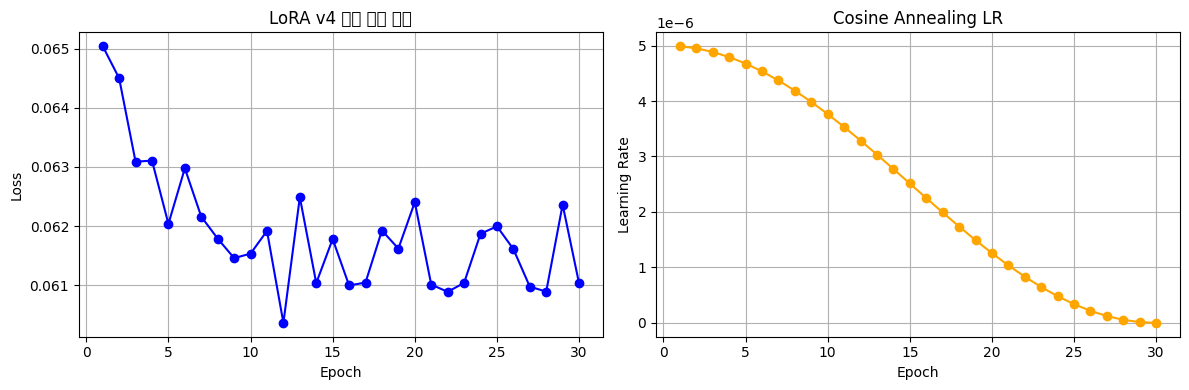

v3 최종 loss: 0.1607
v4 최종 loss: 0.0610
v4 best loss: 0.0604


In [ ]:
# [Step 9] 손실 커브 시각화

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['epoch'], history['avg_loss'], marker='o', color='blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('LoRA v4 학습 손실 커브')
ax1.grid(True)

ax2.plot(history['epoch'], history['lr'], marker='o', color='orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Learning Rate')
ax2.set_title('Cosine Annealing LR')
ax2.grid(True)

plt.tight_layout()
plt.savefig('lora_v4_training.png', dpi=100)
plt.show()
print(f'v3 최종 loss: 0.1607')
print(f'v4 최종 loss: {history["avg_loss"][-1]:.4f}')
print(f'v4 best loss: {min(history["avg_loss"]):.4f}')

/tmp/ipykernel_1660/2433316645.py:54: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1660/2433316645.py:54: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1660/2433316645.py:54: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1660/2433316645.py:54: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1660/2433316645.py:54: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1660/2433316645.py:54: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1660/2433316645.py:54: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tig

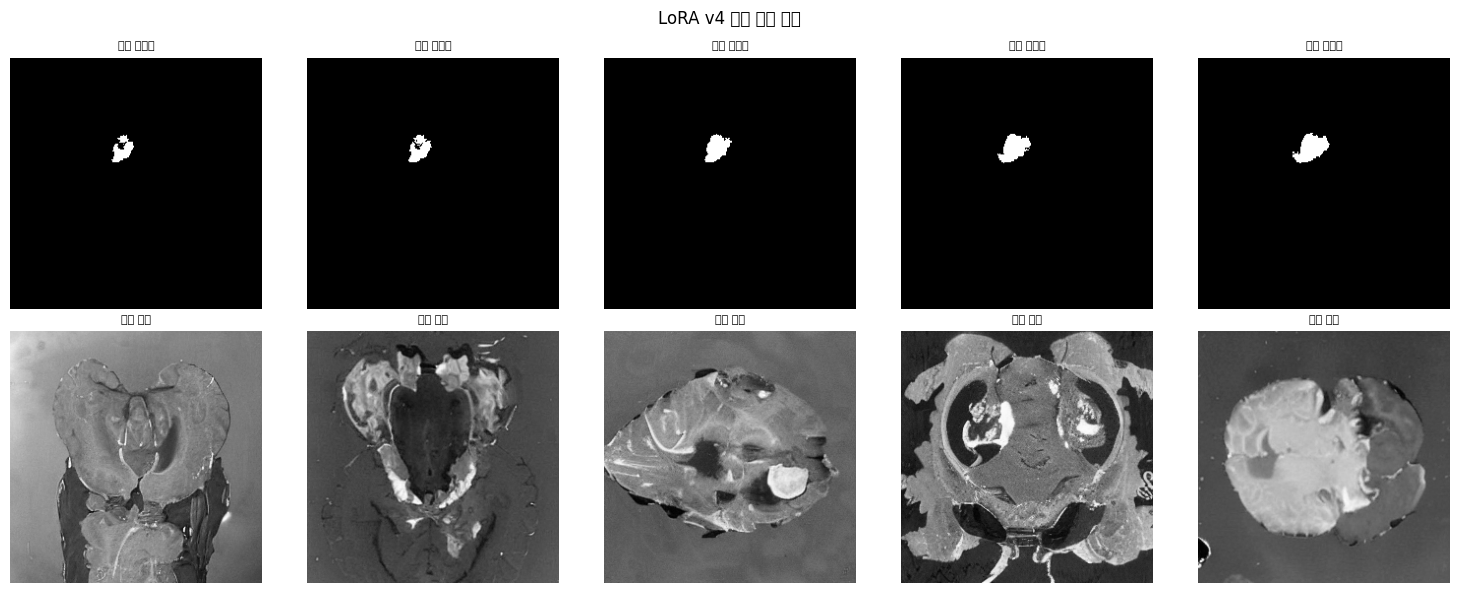

In [ ]:
# [Step 10] 생성 테스트 - 학습 결과 샘플 확인

from diffusers import DDIMScheduler

test_scheduler = DDIMScheduler.from_pretrained(SD15_CACHE, subfolder='scheduler')
test_scheduler.set_timesteps(30)

unet.eval(); mask_encoder.eval(); concat_conv.eval()

@torch.no_grad()
def generate_sample(mask_np):
    """
    mask_np: (256,256) 0/255
    → 생성된 슬라이스: (256,256) 0~255
    """
    mask_t = torch.from_numpy(mask_np.astype(np.float32) / 255.0)
    mask_t = mask_t.unsqueeze(0).unsqueeze(0).to(device)

    mask_latent = mask_encoder(mask_t)    # [1, 4, 32, 32]
    latents     = torch.randn(1, 4, 32, 32, device=device)

    for t in test_scheduler.timesteps:
        conditioned = concat_conv(latents, mask_latent)
        noise_pred  = unet(
            conditioned, t,
            encoder_hidden_states=empty_embeds
        ).sample
        latents = test_scheduler.step(noise_pred, t, latents).prev_sample

    decoded = vae.decode(latents / vae.config.scaling_factor).sample
    img = decoded[0].float().mean(0).cpu().numpy()
    img = ((img + 1) / 2 * 255).clip(0, 255).astype(np.uint8)
    return img

# BraTS 샘플 마스크로 테스트
mask_dir  = Path(BRATS_SLICES) / 'masks'
mask_files = sorted(mask_dir.glob('*.png'))
test_masks = mask_files[:5]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, mp in enumerate(test_masks):
    mask_np = np.array(Image.open(mp).convert('L').resize((256, 256)))
    gen     = generate_sample(mask_np)

    axes[0, i].imshow(mask_np, cmap='gray')
    axes[0, i].set_title('입력 마스크', fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(gen, cmap='gray')
    axes[1, i].set_title('생성 결과', fontsize=8)
    axes[1, i].axis('off')

plt.suptitle('LoRA v4 생성 샘플 확인')
plt.tight_layout()
plt.savefig('lora_v4_samples.png', dpi=100)
plt.show()

# Phase 2: Synthetic Data Generation v7 -- LoRA v4 + Gaussian Blending

In [ ]:
# [수정] Drive 재마운트 + 안정적 마스크 복사 (재시도 로직)

# If running on Google Colab and need to remount:
# from google.colab import drive
# drive.flush_and_unmount()
# drive.mount('/content/drive', force_remount=True)

import shutil, time
from pathlib import Path
from tqdm import tqdm

# 경로 재설정
GDRIVE        = os.environ.get('DATA_ROOT', './data')
BME_DIR       = f'{GDRIVE}/bme'
PROCESSED_DIR = f'{BME_DIR}/processed'
TUMOR_MASKS_V2 = f'{PROCESSED_DIR}/tumor_masks_v2'
NORMAL_SLICES_V2 = f'{PROCESSED_DIR}/normal_slices_v2'

LOCAL_MASKS  = Path('/content/tumor_masks_tmp')
LOCAL_SLICES = Path('/content/normal_slices_tmp')
LOCAL_MASKS.mkdir(parents=True, exist_ok=True)

mask_files = sorted(Path(TUMOR_MASKS_V2).glob('*.png'))
print(f"복사할 마스크: {len(mask_files)}개")

success, fail = 0, 0
for mask_path in tqdm(mask_files):
    dst = LOCAL_MASKS / mask_path.name
    if dst.exists():
        success += 1
        continue
    for attempt in range(5):  # 최대 5회 재시도
        try:
            shutil.copy2(mask_path, dst)
            success += 1
            break
        except Exception as e:
            if attempt == 4:
                fail += 1
            else:
                time.sleep(3)  # 3초 대기 후 재시도

print(f"완료! 성공: {success}개, 실패: {fail}개")
print(f"LOCAL_MASKS: {len(list(LOCAL_MASKS.glob('*.png')))}개")

Mounted at /content/drive
복사할 마스크: 500개


100%|██████████| 500/500 [00:03<00:00, 149.70it/s]

완료! 성공: 500개, 실패: 0개
LOCAL_MASKS: 500개


In [ ]:
# [Phase 2] 합성 데이터 생성 v7 - Resume 가능 + 로컬 캐시 사용

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from pathlib import Path
from PIL import Image
import os, shutil, time
from tqdm import tqdm
import json
import cv2
from diffusers import AutoencoderKL, UNet2DConditionModel, DDIMScheduler
from transformers import CLIPTextModel, CLIPTokenizer

# ──────────────────────────────────────────────
# 0. 경로 설정
# ──────────────────────────────────────────────
LORA_V4_FINAL  = Path(CHECKPOINTS_DIR) / 'lora_gbm_v4' / 'lora_final'
LOCAL_SLICES   = Path('/content/normal_slices_tmp')
LOCAL_MASKS    = Path('/content/tumor_masks_tmp')
SYNTHETIC_V7   = Path(BME_DIR) / 'synthetic_v7'
GT_MASKS_DIR   = SYNTHETIC_V7 / 'gt_masks'
PROGRESS_FILE  = SYNTHETIC_V7 / 'progress.json'  # resume용

SYNTHETIC_V7.mkdir(parents=True, exist_ok=True)
GT_MASKS_DIR.mkdir(parents=True, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device: {device}")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

device: cuda


In [ ]:
# [Phase 2] 합성 데이터 생성 v7 - Resume 가능 + 로컬 캐시 사용

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from pathlib import Path
from PIL import Image
import os, shutil, time
from tqdm import tqdm
import json
import cv2
from diffusers import AutoencoderKL, UNet2DConditionModel, DDIMScheduler
from transformers import CLIPTextModel, CLIPTokenizer

# ──────────────────────────────────────────────
# 0. 경로 설정
# ──────────────────────────────────────────────
LORA_V4_FINAL  = Path(CHECKPOINTS_DIR) / 'lora_gbm_v4' / 'lora_final'
LOCAL_SLICES   = Path('/content/normal_slices_tmp')
LOCAL_MASKS    = Path('/content/tumor_masks_tmp')
SYNTHETIC_V7   = Path(BME_DIR) / 'synthetic_v7'
GT_MASKS_DIR   = SYNTHETIC_V7 / 'gt_masks'
PROGRESS_FILE  = SYNTHETIC_V7 / 'progress.json'  # resume용

SYNTHETIC_V7.mkdir(parents=True, exist_ok=True)
GT_MASKS_DIR.mkdir(parents=True, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device: {device}")

# ──────────────────────────────────────────────
# 1. Resume 상태 확인
# ──────────────────────────────────────────────
if PROGRESS_FILE.exists():
    with open(PROGRESS_FILE) as f:
        progress = json.load(f)
    done_files = set(progress.get('done', []))
    print(f"Resume: 이미 완료된 파일 {len(done_files)}개 → 나머지부터 시작")
else:
    done_files = set()
    print("처음부터 시작")

# ──────────────────────────────────────────────
# 2. 모델 구조 정의
# ──────────────────────────────────────────────
class LoRALinear(nn.Module):
    def __init__(self, linear, rank=16, alpha=16.0):
        super().__init__()
        self.linear = linear
        self.scale  = alpha / rank
        in_f, out_f = linear.in_features, linear.out_features
        self.lora_A = nn.Linear(in_f, rank,  bias=False)
        self.lora_B = nn.Linear(rank, out_f, bias=False)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=np.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)
        for p in self.linear.parameters():
            p.requires_grad = False
    def forward(self, x):
        return self.linear(x) + self.lora_B(self.lora_A(x)) * self.scale

class MaskEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),             nn.SiLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  nn.SiLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  nn.SiLU(),
            nn.Conv2d(64, 4,  3, stride=2, padding=1),
        )
    def forward(self, x):
        return self.encoder(x)

class ConcatConv(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(8, 4, 1)
        nn.init.zeros_(self.proj.bias)
    def forward(self, noisy_latent, mask_latent):
        if mask_latent.shape[-1] != noisy_latent.shape[-1]:
            mask_latent = F.interpolate(
                mask_latent, size=noisy_latent.shape[-2:],
                mode='bilinear', align_corners=False)
        return self.proj(torch.cat([noisy_latent, mask_latent], dim=1))

def inject_lora_to_unet(unet, rank=16, alpha=16.0):
    lora_layers = []
    for name, module in unet.named_modules():
        if isinstance(module, nn.Linear) and any(
            k in name for k in ['to_q', 'to_k', 'to_v', 'to_out']):
            parent_name = '.'.join(name.split('.')[:-1])
            attr_name   = name.split('.')[-1]
            parent = unet
            for part in parent_name.split('.'):
                parent = getattr(parent, part)
            lora_layer = LoRALinear(module, rank=rank, alpha=alpha)
            setattr(parent, attr_name, lora_layer)
            lora_layers.append(lora_layer)
    print(f"LoRA 주입: {len(lora_layers)}개 레이어")
    return unet, lora_layers

# ──────────────────────────────────────────────
# 3. 모델 로드
# ──────────────────────────────────────────────
with open(LORA_V4_FINAL / 'config.json') as f:
    lora_config = json.load(f)
rank  = lora_config.get('rank', 16)
alpha = lora_config.get('alpha', 16.0)

print("SD v1.5 로드 중 (float16)...")
tokenizer    = CLIPTokenizer.from_pretrained(SD15_CACHE, subfolder='tokenizer')
text_encoder = CLIPTextModel.from_pretrained(
    SD15_CACHE, subfolder='text_encoder', torch_dtype=torch.float16).to(device)
vae          = AutoencoderKL.from_pretrained(
    SD15_CACHE, subfolder='vae', torch_dtype=torch.float16).to(device)
unet         = UNet2DConditionModel.from_pretrained(
    SD15_CACHE, subfolder='unet', torch_dtype=torch.float16).to(device)
scheduler    = DDIMScheduler.from_pretrained(SD15_CACHE, subfolder='scheduler')
scheduler.set_timesteps(20)  # 30 → 20으로 속도 개선

unet, lora_layers = inject_lora_to_unet(unet, rank=rank, alpha=alpha)
unet = unet.to(device)

lora_weights = torch.load(LORA_V4_FINAL / 'lora_weights.pt', map_location=device)
for i, layer in enumerate(lora_layers):
    layer.lora_A.weight.data = lora_weights[f'lora_{i}.A'].to(device).half()
    layer.lora_B.weight.data = lora_weights[f'lora_{i}.B'].to(device).half()

mask_encoder = MaskEncoder().to(device).half()
mask_encoder.load_state_dict(
    torch.load(LORA_V4_FINAL / 'mask_encoder.pt', map_location=device))

concat_conv = ConcatConv().to(device).half()
concat_conv.load_state_dict(
    torch.load(LORA_V4_FINAL / 'concat_conv.pt', map_location=device))

vae.eval(); text_encoder.eval(); unet.eval()
mask_encoder.eval(); concat_conv.eval()

with torch.no_grad():
    empty_tokens = tokenizer(
        [''], padding='max_length', max_length=77,
        truncation=True, return_tensors='pt'
    ).input_ids.to(device)
    empty_embeds = text_encoder(empty_tokens)[0]

print(f"모델 로드 완료! GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# ──────────────────────────────────────────────
# 4. 생성 함수
# ──────────────────────────────────────────────
@torch.no_grad()
def generate_tumor_patch(mask_256):
    mask_t = torch.from_numpy(mask_256.astype(np.float32) / 255.0)
    mask_t = mask_t.unsqueeze(0).unsqueeze(0).to(device).half()
    mask_latent = mask_encoder(mask_t)
    latents     = torch.randn(1, 4, 32, 32, device=device, dtype=torch.float16)
    for t in scheduler.timesteps:
        conditioned = concat_conv(latents, mask_latent)
        noise_pred  = unet(conditioned, t,
                           encoder_hidden_states=empty_embeds).sample
        latents = scheduler.step(noise_pred, t, latents).prev_sample
    decoded = vae.decode(latents / vae.config.scaling_factor).sample
    patch   = decoded[0].float().mean(0).cpu().numpy()
    patch   = ((patch + 1) / 2 * 255).clip(0, 255).astype(np.uint8)
    return patch

def gaussian_blend(bg, patch, mask_full, bbox):
    y1, y2, x1, x2 = bbox
    h, w        = y2 - y1, x2 - x1
    patch_crop  = patch[y1:y2, x1:x2]
    mask_crop   = (mask_full[y1:y2, x1:x2] > 127).astype(np.float32)
    blur_r      = max(3, min(h, w) // 6)
    if blur_r % 2 == 0:
        blur_r += 1
    mask_blur    = cv2.GaussianBlur(mask_crop, (blur_r, blur_r), 0)
    bg_crop      = bg[y1:y2, x1:x2].astype(np.float32)
    blended_crop = (patch_crop.astype(np.float32) * mask_blur
                    + bg_crop * (1 - mask_blur)).astype(np.uint8)
    result = bg.copy()
    result[y1:y2, x1:x2] = blended_crop
    return result

def save_progress(done_files):
    with open(PROGRESS_FILE, 'w') as f:
        json.dump({'done': list(done_files)}, f)

# ──────────────────────────────────────────────
# 5. 생성 루프 (Resume 지원)
# ──────────────────────────────────────────────
mask_files = sorted(LOCAL_MASKS.glob('*.png'))

# 아직 안 된 파일만 필터링
remaining = [f for f in mask_files if f.name not in done_files]
print(f"\n전체: {len(mask_files)}개 | 완료: {len(done_files)}개 | 남은: {len(remaining)}개")

success, fail = 0, 0
SAVE_INTERVAL = 10  # 10개마다 progress 저장

for i, mask_path in enumerate(tqdm(remaining)):
    try:
        slice_name = mask_path.name.replace('_mask.png', '.png')
        slice_path = LOCAL_SLICES / slice_name
        if not slice_path.exists():
            fail += 1
            continue

        bg   = np.array(Image.open(slice_path).convert('L').resize((256, 256)))
        mask = np.array(Image.open(mask_path).convert('L').resize((256, 256)))

        ys, xs = np.where(mask > 127)
        if len(ys) == 0:
            fail += 1
            continue
        y1, y2 = int(ys.min()), int(ys.max()) + 1
        x1, x2 = int(xs.min()), int(xs.max()) + 1
        if (y2 - y1) < 8 or (x2 - x1) < 8:
            fail += 1
            continue

        tumor_patch = generate_tumor_patch(mask)
        synthetic   = gaussian_blend(bg, tumor_patch, mask, (y1, y2, x1, x2))

        fname = mask_path.name.replace('_mask.png', '_synthetic.png')
        Image.fromarray(synthetic).save(SYNTHETIC_V7 / fname)
        Image.fromarray(mask).save(GT_MASKS_DIR / mask_path.name)

        done_files.add(mask_path.name)
        success += 1

        # 주기적으로 progress 저장
        if (i + 1) % SAVE_INTERVAL == 0:
            save_progress(done_files)
            print(f"  [{i+1}/{len(remaining)}] progress 저장 완료")

    except Exception as e:
        print(f"오류 {mask_path.name}: {e}")
        fail += 1

# 최종 저장
save_progress(done_files)
print(f"\n완료! 성공: {success}개, 실패: {fail}개")
print(f"총 완료: {len(done_files)}개")

device: cuda
Resume: 이미 완료된 파일 500개 → 나머지부터 시작
SD v1.5 로드 중 (float16)...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


LoRA 주입: 128개 레이어
모델 로드 완료! GPU: 2.04 GB

전체: 500개 | 완료: 500개 | 남은: 0개


0it [00:00, ?it/s]



완료! 성공: 0개, 실패: 0개
총 완료: 500개


합성 이미지: 500개


/tmp/ipykernel_782/831288828.py:46: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_782/831288828.py:46: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_782/831288828.py:46: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_782/831288828.py:46: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_782/831288828.py:46: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_782/831288828.py:46: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_782/831288828.py:46: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

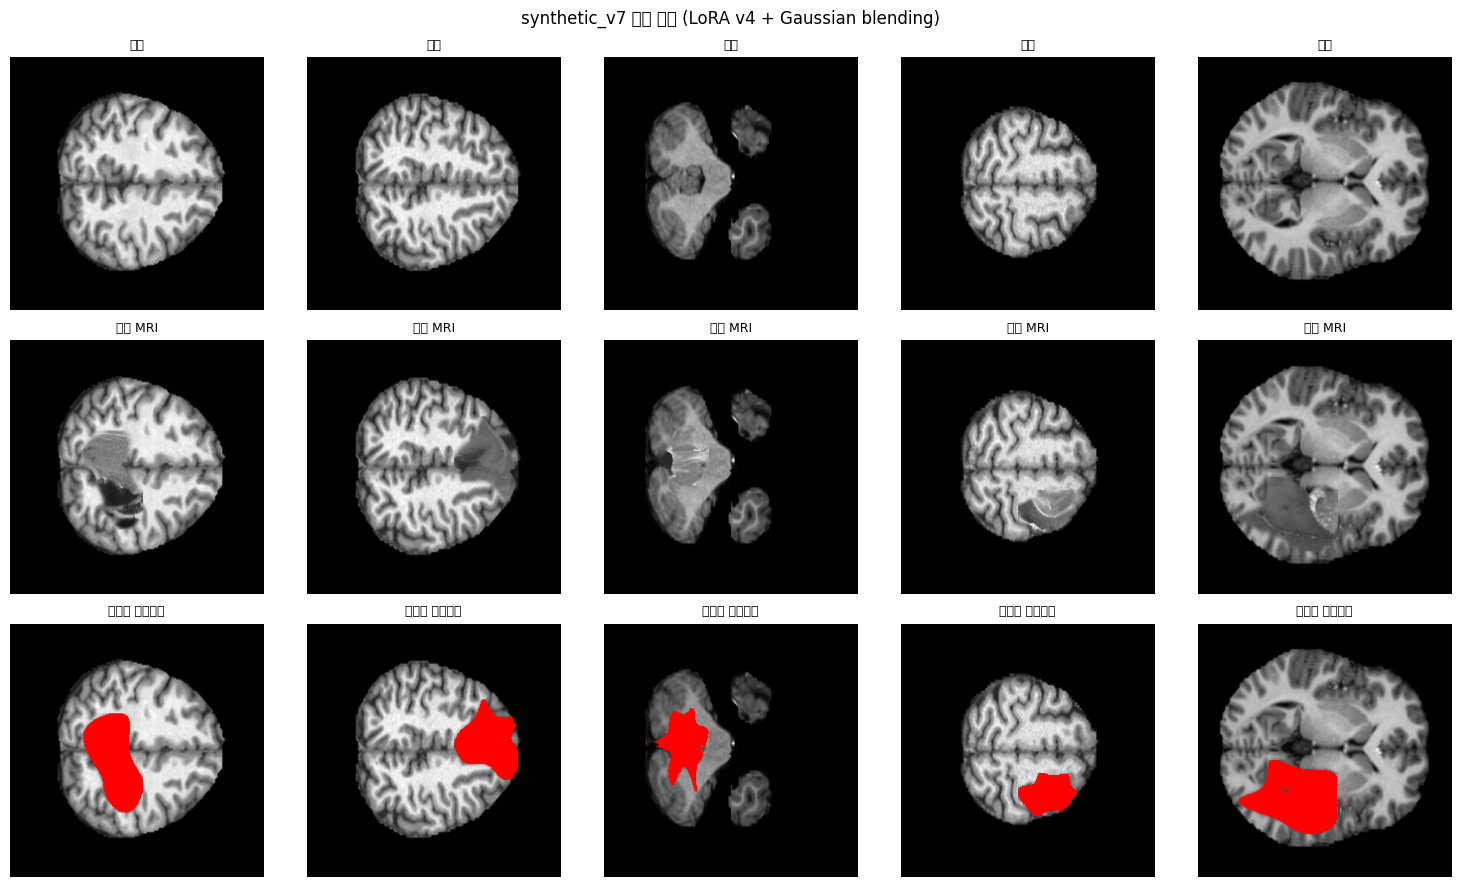

In [ ]:
# [시각화] synthetic_v7 품질 확인 - 원본 / 합성 / 마스크 오버레이

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image
import random

SYNTHETIC_V7 = Path(BME_DIR) / 'synthetic_v7'

synthetic_files = sorted(SYNTHETIC_V7.glob('*_synthetic.png'))
print(f"합성 이미지: {len(synthetic_files)}개")

samples = random.sample(synthetic_files, 5)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for i, syn_path in enumerate(samples):
    # 1행: 원본 슬라이스
    slice_name = syn_path.name.replace('_synthetic.png', '.png')
    slice_path = Path(NORMAL_SLICES_V2) / slice_name
    orig = np.array(Image.open(slice_path).convert('L'))
    axes[0, i].imshow(orig, cmap='gray')
    axes[0, i].set_title('원본', fontsize=9)
    axes[0, i].axis('off')

    # 2행: 합성 이미지
    syn = np.array(Image.open(syn_path).convert('L'))
    axes[1, i].imshow(syn, cmap='gray')
    axes[1, i].set_title('합성 MRI', fontsize=9)
    axes[1, i].axis('off')

    # 3행: 마스크 오버레이
    mask_name = syn_path.name.replace('_synthetic.png', '_mask.png')
    mask_path = SYNTHETIC_V7 / 'gt_masks' / mask_name
    mask = np.array(Image.open(mask_path).convert('L'))
    overlay = np.stack([syn, syn, syn], axis=-1).astype(np.float32)
    overlay[mask > 127, 0] = 255
    overlay[mask > 127, 1] = 0
    overlay[mask > 127, 2] = 0
    axes[2, i].imshow(overlay.astype(np.uint8))
    axes[2, i].set_title('마스크 오버레이', fontsize=9)
    axes[2, i].axis('off')

plt.suptitle('synthetic_v7 품질 확인 (LoRA v4 + Gaussian blending)', fontsize=12)
plt.tight_layout()
plt.savefig('synthetic_v7_check.png', dpi=100)
plt.show()

In [ ]:
# [Step 0] 경로 설정

# If running on Google Colab, mount Drive first:
# from google.colab import drive
# drive.mount('/content/drive')
import os

GDRIVE   = os.environ.get('DATA_ROOT', './data')
BME_DIR  = f'{GDRIVE}/bme'

PROCESSED_DIR    = f'{BME_DIR}/processed'
BRATS_SLICES     = f'{PROCESSED_DIR}/brats_slices'
NORMAL_SLICES_V2 = f'{PROCESSED_DIR}/normal_slices_v2'
TUMOR_MASKS_V2   = f'{PROCESSED_DIR}/tumor_masks_v2'
CHECKPOINTS_DIR  = f'{BME_DIR}/checkpoints'
RESULTS_DIR      = f'{BME_DIR}/results'
SD15_CACHE       = f'{BME_DIR}/sd15_cache'
SYNTHETIC_V7     = f'{BME_DIR}/synthetic_v7'

print("경로 설정 완료!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
경로 설정 완료!


In [ ]:
# [수정] Resume 지원 - 학습 루프 실행 전에 이 코드 먼저 실행

LORA_V4_FINAL  = Path(CHECKPOINTS_DIR) / 'lora_gbm_v4' / 'lora_final'
LOCAL_SLICES   = Path('/content/normal_slices_tmp')
LOCAL_MASKS    = Path('/content/tumor_masks_tmp')
SYNTHETIC_V7   = Path(BME_DIR) / 'synthetic_v7'
GT_MASKS_DIR   = SYNTHETIC_V7 / 'gt_masks'
PROGRESS_FILE  = SYNTHETIC_V7 / 'progress.json'  # resume용

SYNTHETIC_V7.mkdir(parents=True, exist_ok=True)
GT_MASKS_DIR.mkdir(parents=True, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device: {device}")
NUM_EPOCHS = 30
scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

# Resume 체크
start_epoch = 1
best_dice   = baseline_dice
history     = {'epoch':[], 'train_loss':[], 'dice':[], 'iou':[], 'hd95':[]}

epoch_ckpts = sorted(FINETUNE_CKPT.glob('epoch_*.pth'))
if epoch_ckpts:
    latest = epoch_ckpts[-1]
    print(f"Resume 체크포인트 발견: {latest.name}")
    ckpt_resume = torch.load(latest, map_location=device, weights_only=False)
    model.load_state_dict(ckpt_resume['model'])
    history     = ckpt_resume['history']
    best_dice   = ckpt_resume['best_dice']
    start_epoch = ckpt_resume['epoch'] + 1

    optimizer.load_state_dict(ckpt_resume.get('optimizer', optimizer.state_dict()))
    for _ in range(ckpt_resume['epoch']):
        scheduler_lr.step()

    print(f"Epoch {start_epoch}부터 재시작 | best_dice={best_dice:.4f}")
else:
    print("처음부터 시작")

print(f"남은 epoch: {NUM_EPOCHS - start_epoch + 1}개")

In [ ]:
# [Phase 3] 베이스라인 Fine-tuning + 평가 (기존 unet.py 구조 사용)

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import cv2, json, os, random
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device: {device}")

SYNTHETIC_V7  = Path(BME_DIR) / 'synthetic_v7'
FINETUNE_CKPT = Path(CHECKPOINTS_DIR) / 'seg_finetune_v7'
BASELINE_CKPT = Path(CHECKPOINTS_DIR) / 'seg_baseline_1000' / 'best.pth'
FINETUNE_CKPT.mkdir(parents=True, exist_ok=True)

# ──────────────────────────────────────────────
# 1. 기존 unet.py와 동일한 모델 구조
# ──────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)

class DownSample(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = ConvBlock(in_ch, out_ch, dropout)
    def forward(self, x): return self.conv(self.pool(x))

class UpSample(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.0):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = ConvBlock(in_ch + skip_ch, out_ch, dropout)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.pad(x, [0, skip.shape[-1]-x.shape[-1],
                          0, skip.shape[-2]-x.shape[-2]])
        return self.conv(torch.cat([x, skip], dim=1))

class AttentionGate(nn.Module):
    def __init__(self, g_ch, x_ch, inter_ch):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_ch, inter_ch, 1, bias=False), nn.BatchNorm2d(inter_ch))
        self.W_x = nn.Sequential(
            nn.Conv2d(x_ch, inter_ch, 1, bias=False), nn.BatchNorm2d(inter_ch))
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, 1, bias=False), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        g1 = self.W_g(g); x1 = self.W_x(x)
        if g1.shape[-2:] != x1.shape[-2:]:
            g1 = F.interpolate(g1, size=x1.shape[-2:],
                               mode='bilinear', align_corners=True)
        return x * self.psi(self.relu(g1 + x1))

class AttentionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1,
                 features=None, dropout=0.2):
        super().__init__()
        if features is None:
            features = [64, 128, 256, 512]

        self.enc1       = ConvBlock(in_channels, features[0])
        self.enc2       = DownSample(features[0], features[1], dropout)
        self.enc3       = DownSample(features[1], features[2], dropout)
        self.enc4       = DownSample(features[2], features[3], dropout)
        self.bottleneck = DownSample(features[3], features[3]*2, dropout)

        self.att4 = AttentionGate(features[3]*2, features[3], features[3]//2)
        self.att3 = AttentionGate(features[3],   features[2], features[2]//2)
        self.att2 = AttentionGate(features[2],   features[1], features[1]//2)
        self.att1 = AttentionGate(features[1],   features[0], features[0]//2)

        self.dec4 = UpSample(features[3]*2, features[3], features[3], dropout)
        self.dec3 = UpSample(features[3],   features[2], features[2], dropout)
        self.dec2 = UpSample(features[2],   features[1], features[1], dropout)
        self.dec1 = UpSample(features[1],   features[0], features[0], dropout)

        self.head = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        b  = self.bottleneck(s4)
        d4 = self.dec4(b,  self.att4(b,  s4))
        d3 = self.dec3(d4, self.att3(d4, s3))
        d2 = self.dec2(d3, self.att2(d3, s2))
        d1 = self.dec1(d2, self.att1(d2, s1))
        return self.head(d1)

# ──────────────────────────────────────────────
# 2. 데이터셋
# ──────────────────────────────────────────────
class BraTSDataset(Dataset):
    def __init__(self, brats_dir, split='test',
                 val_ratio=0.15, test_ratio=0.10, seed=42):
        img_dir  = Path(brats_dir) / 'images'
        mask_dir = Path(brats_dir) / 'masks'
        all_imgs = sorted(img_dir.glob('*_t1ce.png'))
        pairs = []
        for ip in all_imgs:
            mp = mask_dir / ip.name.replace('_t1ce', '_seg')
            if mp.exists():
                pairs.append((ip, mp))
        rng = random.Random(seed)
        rng.shuffle(pairs)
        n      = len(pairs)
        n_test = max(1, int(n * test_ratio))
        n_val  = max(1, int(n * val_ratio))
        if split == 'test':
            self.pairs = pairs[:n_test]
        elif split == 'val':
            self.pairs = pairs[n_test:n_test+n_val]
        else:
            self.pairs = pairs[n_test+n_val:]
        print(f"BraTSDataset [{split}]: {len(self.pairs)}장")

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        ip, mp = self.pairs[idx]
        img  = np.array(Image.open(ip).convert('L'),
                        dtype=np.float32) / 255.0
        mask = (np.array(Image.open(mp).convert('L')) > 0).astype(np.float32)
        img  = cv2.resize(img,  (256,256), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (256,256), interpolation=cv2.INTER_NEAREST)
        return {
            'image': torch.from_numpy(img).unsqueeze(0).float(),
            'mask':  torch.from_numpy(mask).unsqueeze(0).float()
        }

class SyntheticDataset(Dataset):
    def __init__(self, syn_dir, augment=True):
        self.syn_dir   = Path(syn_dir)
        self.augment   = augment
        self.img_files = sorted(self.syn_dir.glob('*_synthetic.png'))
        print(f"SyntheticDataset: {len(self.img_files)}장")

    def __len__(self): return len(self.img_files)

    def __getitem__(self, idx):
        img_path  = self.img_files[idx]
        mask_name = img_path.name.replace('_synthetic.png', '_mask.png')
        mask_path = self.syn_dir / 'gt_masks' / mask_name
        img  = np.array(Image.open(img_path).convert('L').resize((256,256)),
                        dtype=np.float32) / 255.0
        mask = (np.array(Image.open(mask_path).convert('L').resize((256,256)))
                > 127).astype(np.float32)
        if self.augment:
            if np.random.rand() > 0.5:
                img  = np.fliplr(img).copy()
                mask = np.fliplr(mask).copy()
            if np.random.rand() > 0.5:
                img  = np.flipud(img).copy()
                mask = np.flipud(mask).copy()
            angle = np.random.uniform(-30, 30)
            M = cv2.getRotationMatrix2D((128,128), angle, 1.0)
            img  = cv2.warpAffine(img,  M, (256,256), flags=cv2.INTER_LINEAR)
            mask = cv2.warpAffine(mask, M, (256,256), flags=cv2.INTER_NEAREST)
        return {
            'image': torch.from_numpy(img).unsqueeze(0).float(),
            'mask':  torch.from_numpy(mask).unsqueeze(0).float()
        }

# ──────────────────────────────────────────────
# 3. 손실 함수 및 평가 지표
# ──────────────────────────────────────────────
def dice_loss(pred, target, smooth=1e-6):
    pred  = torch.sigmoid(pred)
    inter = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    return 1 - ((2*inter+smooth)/(union+smooth)).mean()

def combined_loss(pred, target):
    return (0.6*dice_loss(pred,target) +
            0.4*F.binary_cross_entropy_with_logits(pred,target))

@torch.no_grad()
def compute_metrics(pred_logits, target):
    pred      = (torch.sigmoid(pred_logits) > 0.5).float()
    pred_np   = pred.cpu().numpy().astype(bool)
    target_np = target.cpu().numpy().astype(bool)
    d_list, i_list, h_list = [], [], []
    for p, t in zip(pred_np, target_np):
        p = p[0]; t = t[0]
        inter = (p & t).sum()
        d_list.append((2*inter) / (p.sum()+t.sum()+1e-6))
        i_list.append(inter / ((p|t).sum()+1e-6))
        if p.sum() > 0 and t.sum() > 0:
            hd1 = distance_transform_edt(~p)[t].max()
            hd2 = distance_transform_edt(~t)[p].max()
            h_list.append(float(np.percentile([hd1,hd2], 95)))
        else:
            h_list.append(373.0)
    return np.mean(d_list), np.mean(i_list), np.mean(h_list)

# ──────────────────────────────────────────────
# 4. 모델 로드
# ──────────────────────────────────────────────
model = AttentionUNet(in_channels=1, out_channels=1,
                      features=[64,128,256,512], dropout=0.2).to(device)
ckpt  = torch.load(BASELINE_CKPT, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model'])
print(f"베이스라인 로드 완료! epoch={ckpt['epoch']}, best_dice={ckpt['best_dice']:.4f}")

# ──────────────────────────────────────────────
# 5. 데이터로더
# ──────────────────────────────────────────────
test_dataset = BraTSDataset(BRATS_SLICES, split='test',
                             val_ratio=0.15, test_ratio=0.10, seed=42)
test_loader  = DataLoader(test_dataset, batch_size=16,
                          shuffle=False, num_workers=2)
syn_dataset  = SyntheticDataset(SYNTHETIC_V7, augment=True)
syn_loader   = DataLoader(syn_dataset, batch_size=16,
                          shuffle=True, num_workers=2, drop_last=True)

# ──────────────────────────────────────────────
# 6. 베이스라인 성능 측정
# ──────────────────────────────────────────────
model.eval()
d_list, i_list, h_list = [], [], []
for batch in tqdm(test_loader, desc='베이스라인 평가'):
    imgs  = batch['image'].to(device)
    masks = batch['mask'].to(device)
    with torch.no_grad():
        preds = model(imgs)
    d, i, h = compute_metrics(preds, masks)
    d_list.append(d); i_list.append(i); h_list.append(h)

baseline_dice = np.mean(d_list)
baseline_iou  = np.mean(i_list)
baseline_hd95 = np.mean(h_list)
print(f"\n베이스라인 성능:")
print(f"  Dice: {baseline_dice:.4f}")
print(f"  IoU:  {baseline_iou:.4f}")
print(f"  HD95: {baseline_hd95:.4f}")

# ──────────────────────────────────────────────
# 7. Fine-tuning
# ──────────────────────────────────────────────
optimizer    = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-5)
scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
scaler       = torch.cuda.amp.GradScaler()

NUM_EPOCHS = 20
best_dice  = baseline_dice
history    = {'epoch':[], 'train_loss':[], 'dice':[], 'iou':[], 'hd95':[]}

print(f"\nFine-tuning 시작: {NUM_EPOCHS} epoch")
print(f"베이스라인 Dice {baseline_dice:.4f} 넘으면 성공!")
print('-' * 50)

# [수정] 학습 루프 시작 epoch 변경
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for batch in tqdm(syn_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}'):
        imgs  = batch['image'].to(device)
        masks = batch['mask'].to(device)
        with torch.amp.autocast('cuda'):
            preds = model(imgs)
            loss  = combined_loss(preds, masks)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item()
    scheduler_lr.step()
    avg_loss = total_loss / len(syn_loader)

    model.eval()
    d_list, i_list, h_list = [], [], []
    for batch in test_loader:
        imgs  = batch['image'].to(device)
        masks = batch['mask'].to(device)
        with torch.no_grad():
            preds = model(imgs)
        d, i, h = compute_metrics(preds, masks)
        d_list.append(d); i_list.append(i); h_list.append(h)

    epoch_dice = np.mean(d_list)
    epoch_iou  = np.mean(i_list)
    epoch_hd95 = np.mean(h_list)

    history['epoch'].append(epoch)
    history['train_loss'].append(avg_loss)
    history['dice'].append(float(epoch_dice))
    history['iou'].append(float(epoch_iou))
    history['hd95'].append(float(epoch_hd95))

    print(f"Epoch {epoch:02d} | loss={avg_loss:.4f} | "
          f"Dice={epoch_dice:.4f} | IoU={epoch_iou:.4f} | HD95={epoch_hd95:.2f}")

    if epoch_dice > best_dice:
        best_dice = epoch_dice
        # [수정] 매 epoch 저장 - optimizer 추가
        torch.save({
            'epoch': epoch,
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'history': history,
            'best_dice': best_dice,
        }, FINETUNE_CKPT / f'epoch_{epoch:02d}.pth')
        print(f"  → Best 갱신! Dice={best_dice:.4f} ✅")

    torch.save({'epoch': epoch, 'model': model.state_dict(),
                'history': history, 'best_dice': best_dice},
               FINETUNE_CKPT / f'epoch_{epoch:02d}.pth')

# ──────────────────────────────────────────────
# 8. 최종 결과 비교 및 시각화
# ──────────────────────────────────────────────
best_result = torch.load(FINETUNE_CKPT / 'best.pth', map_location='cpu')
print(f"\n{'='*50}")
print(f"{'':20s} {'Dice':>8} {'IoU':>8} {'HD95':>8}")
print(f"{'-'*50}")
print(f"{'베이스라인':20s} {baseline_dice:>8.4f} {baseline_iou:>8.4f} {baseline_hd95:>8.2f}")
print(f"{'제안 방법 (best)':20s} {best_result['dice']:>8.4f} "
      f"{best_result['iou']:>8.4f} {best_result['hd95']:>8.2f}")
print(f"{'='*50}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['epoch'], history['train_loss'], marker='o')
axes[0].set_title('Fine-tuning Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True)

axes[1].plot(history['epoch'], history['dice'], marker='o',
             color='blue', label='Fine-tuned')
axes[1].axhline(y=baseline_dice, color='red', linestyle='--',
                label=f'Baseline ({baseline_dice:.4f})')
axes[1].set_title('Dice Score'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

axes[2].plot(history['epoch'], history['hd95'], marker='o', color='green')
axes[2].axhline(y=baseline_hd95, color='red', linestyle='--',
                label=f'Baseline ({baseline_hd95:.2f})')
axes[2].set_title('HD95 (낮을수록 좋음)'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(True)

plt.suptitle('Fine-tuning 결과: 베이스라인 vs 제안 방법')
plt.tight_layout()
plt.savefig('finetune_results.png', dpi=100)
plt.show()

with open(FINETUNE_CKPT / 'history.json', 'w') as f:
    json.dump(history, f, indent=2)
print("완료!")

device: cuda
베이스라인 로드 완료! epoch=29, best_dice=0.8721


In [ ]:
# [확인] 현재까지 fine-tuning 결과 확인

import json
from pathlib import Path

# history에서 결과 확인
if 'history' in dir() and history['epoch']:
    print(f"현재까지 완료된 epoch: {max(history['epoch'])}")
    print(f"\nEpoch별 결과:")
    for e, d, i, h in zip(history['epoch'], history['dice'],
                           history['iou'], history['hd95']):
        marker = ' ★' if d > baseline_dice else ''
        print(f"  Epoch {e:02d} | Dice={d:.4f} | IoU={i:.4f} | HD95={h:.2f}{marker}")
    print(f"\n베이스라인: Dice={baseline_dice:.4f}")
    print(f"현재 Best: Dice={max(history['dice']):.4f} (Epoch {history['epoch'][history['dice'].index(max(history['dice']))]})")
else:
    # epoch 체크포인트에서 직접 읽기
    ckpts = sorted(Path(CHECKPOINTS_DIR / 'seg_finetune_v7').glob('epoch_*.pth'))
    print(f"저장된 체크포인트: {[c.name for c in ckpts]}")
    if ckpts:
        latest = torch.load(ckpts[-1], map_location='cpu', weights_only=False)
        print(f"최신 epoch: {latest['epoch']}")
        print(f"history: {latest['history']}")

In [ ]:
# [확인] 베이스라인 학습에 사용된 데이터 범위 확인

brats_train_full = BraTSDataset(BRATS_SLICES, split='train',
                                val_ratio=0.15, test_ratio=0.10, seed=42)
brats_val        = BraTSDataset(BRATS_SLICES, split='val',
                                val_ratio=0.15, test_ratio=0.10, seed=42)
brats_test       = BraTSDataset(BRATS_SLICES, split='test',
                                val_ratio=0.15, test_ratio=0.10, seed=42)

total = len(brats_train_full) + len(brats_val) + len(brats_test)
print(f"전체: {total}장")
print(f"train: {len(brats_train_full)}장 ← 베이스라인이 학습한 데이터")
print(f"val:   {len(brats_val)}장")
print(f"test:  {len(brats_test)}장 ← 평가용")
print(f"\n베이스라인 학습 데이터: 1,000장")
print(f"→ train split {len(brats_train_full)}장 중 1,000장만 사용했을 가능성 있음")

NameError: name 'BraTSDataset' is not defined

device: cuda
BraTSDataset [test]: 1999장
BraTSDataset [train]: 14998장
train/test 겹치는 파일: 0개 ← 0이어야 정상!
SyntheticDataset: 500장
혼합 데이터셋: 800장 (50 배치)


/tmp/ipykernel_1232/3506840348.py:276: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler_lr.step()
/tmp/ipykernel_1232/3506840348.py:306: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Resume: epoch 10부터 | best_dice=0.8731

Mixed Fine-tuning | epoch 10~30 | lr=5e-6
베이스라인 Dice 0.8731 넘으면 성공!
--------------------------------------------------


Epoch 10/30: 100%|██████████| 50/50 [00:30<00:00,  1.67it/s]


Epoch 10 | loss=0.1961 | Dice=0.8576 | IoU=0.7650 | HD95=13.52


...

Epoch 29/30: 100%|██████████| 50/50 [00:28<00:00,  1.75it/s]


Epoch 29 | loss=0.1846 | Dice=0.8520 | IoU=0.7579 | HD95=14.32


Epoch 30/30: 100%|██████████| 50/50 [00:28<00:00,  1.78it/s]


Epoch 30 | loss=0.1828 | Dice=0.8506 | IoU=0.7566 | HD95=14.53

                         Dice      IoU     HD95
--------------------------------------------------
베이스라인                  0.8731   0.0000     0.00
제안 방법                  0.8661 (베이스라인 미달)


/tmp/ipykernel_1232/3506840348.py:412: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1232/3506840348.py:412: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1232/3506840348.py:412: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1232/3506840348.py:412: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1232/3506840348.py:412: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1232/3506840348.py:412: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1232/3506840348.py:412: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  plt.tight_l

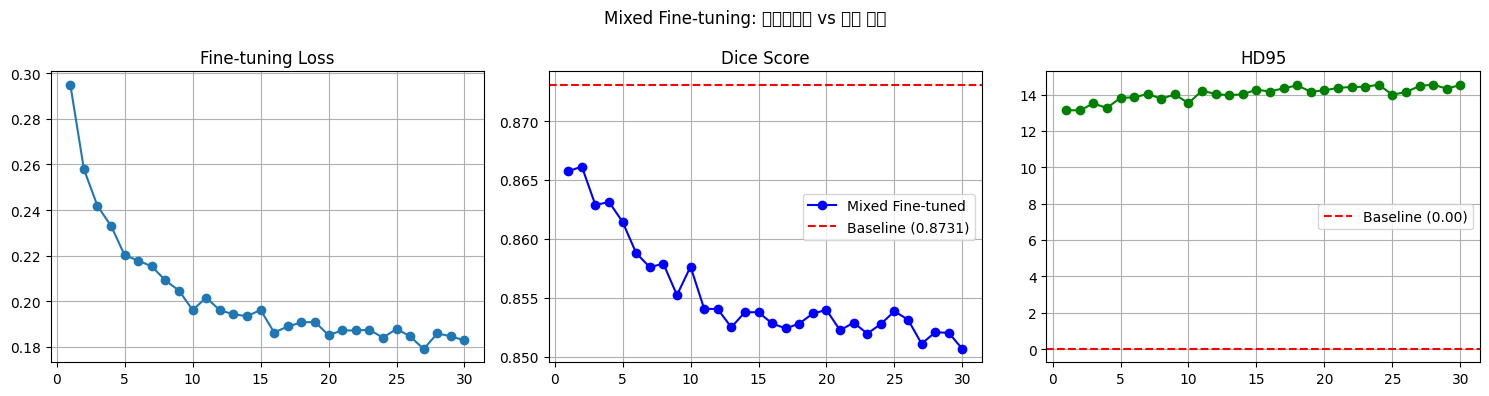

완료!


In [ ]:
# [Phase 3-v2] Mixed Fine-tuning - Resume 완전 지원 버전

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import cv2, json, os, random
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device: {device}")

SYNTHETIC_V7  = Path(BME_DIR) / 'synthetic_v7'
FINETUNE_V2   = Path(CHECKPOINTS_DIR) / 'seg_finetune_v7_mixed'
BASELINE_CKPT = Path(CHECKPOINTS_DIR) / 'seg_baseline_1000' / 'best.pth'
FINETUNE_V2.mkdir(parents=True, exist_ok=True)

# ──────────────────────────────────────────────
# 1. 모델 구조
# ──────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)

class DownSample(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = ConvBlock(in_ch, out_ch, dropout)
    def forward(self, x): return self.conv(self.pool(x))

class UpSample(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.0):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = ConvBlock(in_ch + skip_ch, out_ch, dropout)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.pad(x, [0, skip.shape[-1]-x.shape[-1],
                          0, skip.shape[-2]-x.shape[-2]])
        return self.conv(torch.cat([x, skip], dim=1))

class AttentionGate(nn.Module):
    def __init__(self, g_ch, x_ch, inter_ch):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_ch, inter_ch, 1, bias=False), nn.BatchNorm2d(inter_ch))
        self.W_x = nn.Sequential(
            nn.Conv2d(x_ch, inter_ch, 1, bias=False), nn.BatchNorm2d(inter_ch))
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, 1, bias=False), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        g1 = self.W_g(g); x1 = self.W_x(x)
        if g1.shape[-2:] != x1.shape[-2:]:
            g1 = F.interpolate(g1, size=x1.shape[-2:],
                               mode='bilinear', align_corners=True)
        return x * self.psi(self.relu(g1 + x1))

class AttentionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1,
                 features=None, dropout=0.2):
        super().__init__()
        if features is None:
            features = [64, 128, 256, 512]
        self.enc1       = ConvBlock(in_channels, features[0])
        self.enc2       = DownSample(features[0], features[1], dropout)
        self.enc3       = DownSample(features[1], features[2], dropout)
        self.enc4       = DownSample(features[2], features[3], dropout)
        self.bottleneck = DownSample(features[3], features[3]*2, dropout)
        self.att4 = AttentionGate(features[3]*2, features[3], features[3]//2)
        self.att3 = AttentionGate(features[3],   features[2], features[2]//2)
        self.att2 = AttentionGate(features[2],   features[1], features[1]//2)
        self.att1 = AttentionGate(features[1],   features[0], features[0]//2)
        self.dec4 = UpSample(features[3]*2, features[3], features[3], dropout)
        self.dec3 = UpSample(features[3],   features[2], features[2], dropout)
        self.dec2 = UpSample(features[2],   features[1], features[1], dropout)
        self.dec1 = UpSample(features[1],   features[0], features[0], dropout)
        self.head = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        b  = self.bottleneck(s4)
        d4 = self.dec4(b,  self.att4(b,  s4))
        d3 = self.dec3(d4, self.att3(d4, s3))
        d2 = self.dec2(d3, self.att2(d3, s2))
        d1 = self.dec1(d2, self.att1(d2, s1))
        return self.head(d1)

# ──────────────────────────────────────────────
# 2. 데이터셋
# ──────────────────────────────────────────────
class BraTSDataset(Dataset):
    def __init__(self, brats_dir, split='train',
                 val_ratio=0.15, test_ratio=0.10, seed=42):
        img_dir  = Path(brats_dir) / 'images'
        mask_dir = Path(brats_dir) / 'masks'
        all_imgs = sorted(img_dir.glob('*_t1ce.png'))
        pairs = []
        for ip in all_imgs:
            mp = mask_dir / ip.name.replace('_t1ce', '_seg')
            if mp.exists():
                pairs.append((ip, mp))
        rng = random.Random(seed)
        rng.shuffle(pairs)
        n      = len(pairs)
        n_test = max(1, int(n * test_ratio))
        n_val  = max(1, int(n * val_ratio))
        if split == 'test':
            self.pairs = pairs[:n_test]
        elif split == 'val':
            self.pairs = pairs[n_test:n_test+n_val]
        else:
            self.pairs = pairs[n_test+n_val:]
        print(f"BraTSDataset [{split}]: {len(self.pairs)}장")

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        ip, mp = self.pairs[idx]
        img  = np.array(Image.open(ip).convert('L'),
                        dtype=np.float32) / 255.0
        mask = (np.array(Image.open(mp).convert('L')) > 0).astype(np.float32)
        img  = cv2.resize(img,  (256,256), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (256,256), interpolation=cv2.INTER_NEAREST)
        if np.random.rand() > 0.5:
            img  = np.fliplr(img).copy()
            mask = np.fliplr(mask).copy()
        return {
            'image': torch.from_numpy(img).unsqueeze(0).float(),
            'mask':  torch.from_numpy(mask).unsqueeze(0).float()
        }

class SyntheticDataset(Dataset):
    def __init__(self, syn_dir, augment=True):
        self.syn_dir   = Path(syn_dir)
        self.img_files = sorted(self.syn_dir.glob('*_synthetic.png'))
        self.augment   = augment
        print(f"SyntheticDataset: {len(self.img_files)}장")

    def __len__(self): return len(self.img_files)

    def __getitem__(self, idx):
        img_path  = self.img_files[idx]
        mask_name = img_path.name.replace('_synthetic.png', '_mask.png')
        mask_path = self.syn_dir / 'gt_masks' / mask_name
        img  = np.array(Image.open(img_path).convert('L').resize((256,256)),
                        dtype=np.float32) / 255.0
        mask = (np.array(Image.open(mask_path).convert('L').resize((256,256)))
                > 127).astype(np.float32)
        if self.augment:
            if np.random.rand() > 0.5:
                img  = np.fliplr(img).copy()
                mask = np.fliplr(mask).copy()
            if np.random.rand() > 0.5:
                img  = np.flipud(img).copy()
                mask = np.flipud(mask).copy()
            angle = np.random.uniform(-30, 30)
            M = cv2.getRotationMatrix2D((128,128), angle, 1.0)
            img  = cv2.warpAffine(img,  M, (256,256), flags=cv2.INTER_LINEAR)
            mask = cv2.warpAffine(mask, M, (256,256), flags=cv2.INTER_NEAREST)
        return {
            'image': torch.from_numpy(img).unsqueeze(0).float(),
            'mask':  torch.from_numpy(mask).unsqueeze(0).float()
        }

# ──────────────────────────────────────────────
# 3. 손실 함수 및 평가 지표
# ──────────────────────────────────────────────
def dice_loss(pred, target, smooth=1e-6):
    pred  = torch.sigmoid(pred)
    inter = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    return 1 - ((2*inter+smooth)/(union+smooth)).mean()

def combined_loss(pred, target):
    return (0.6*dice_loss(pred,target) +
            0.4*F.binary_cross_entropy_with_logits(pred,target))

@torch.no_grad()
def compute_metrics(pred_logits, target):
    pred      = (torch.sigmoid(pred_logits) > 0.5).float()
    pred_np   = pred.cpu().numpy().astype(bool)
    target_np = target.cpu().numpy().astype(bool)
    d_list, i_list, h_list = [], [], []
    for p, t in zip(pred_np, target_np):
        p = p[0]; t = t[0]
        inter = (p & t).sum()
        d_list.append((2*inter) / (p.sum()+t.sum()+1e-6))
        i_list.append(inter / ((p|t).sum()+1e-6))
        if p.sum() > 0 and t.sum() > 0:
            hd1 = distance_transform_edt(~p)[t].max()
            hd2 = distance_transform_edt(~t)[p].max()
            h_list.append(float(np.percentile([hd1,hd2], 95)))
        else:
            h_list.append(373.0)
    return np.mean(d_list), np.mean(i_list), np.mean(h_list)

# ──────────────────────────────────────────────
# 4. 데이터 분리 확인
# ──────────────────────────────────────────────
test_dataset  = BraTSDataset(BRATS_SLICES, split='test',
                              val_ratio=0.15, test_ratio=0.10, seed=42)
brats_train   = BraTSDataset(BRATS_SLICES, split='train',
                              val_ratio=0.15, test_ratio=0.10, seed=42)

train_names = set(str(p[0].name) for p in brats_train.pairs)
test_names  = set(str(p[0].name) for p in test_dataset.pairs)
overlap     = train_names & test_names
print(f"train/test 겹치는 파일: {len(overlap)}개 ← 0이어야 정상!")
assert len(overlap) == 0, "train/test 데이터 겹침 발생!"

# ──────────────────────────────────────────────
# 5. 데이터로더
# ──────────────────────────────────────────────
test_loader = DataLoader(test_dataset, batch_size=16,
                         shuffle=False, num_workers=2)

syn_dataset   = SyntheticDataset(SYNTHETIC_V7, augment=True)
random.seed(42)
brats_indices = random.sample(range(len(brats_train)), min(300, len(brats_train)))
brats_subset  = torch.utils.data.Subset(brats_train, brats_indices)
mixed_dataset = ConcatDataset([syn_dataset, brats_subset])
mixed_loader  = DataLoader(mixed_dataset, batch_size=16,
                           shuffle=True, num_workers=2, drop_last=True)
print(f"혼합 데이터셋: {len(mixed_dataset)}장 ({len(mixed_loader)} 배치)")

# ──────────────────────────────────────────────
# 6. 모델 + Resume 체크
# ──────────────────────────────────────────────
model = AttentionUNet(in_channels=1, out_channels=1,
                      features=[64,128,256,512], dropout=0.2).to(device)

NUM_EPOCHS  = 30
start_epoch = 1
history     = {'epoch':[], 'train_loss':[], 'dice':[], 'iou':[], 'hd95':[]}

# ── Resume: 저장된 epoch 체크포인트 있으면 이어서 ──
epoch_ckpts = sorted(FINETUNE_V2.glob('epoch_*.pth'))
if epoch_ckpts:
    latest  = epoch_ckpts[-1]
    ckpt_r  = torch.load(latest, map_location=device, weights_only=False)
    model.load_state_dict(ckpt_r['model'])
    history     = ckpt_r['history']
    start_epoch = ckpt_r['epoch'] + 1
    best_dice   = ckpt_r['best_dice']

    # baseline_dice도 history에서 복원
    baseline_dice = ckpt_r.get('baseline_dice', 0.8731)
    baseline_iou  = ckpt_r.get('baseline_iou',  0.0)
    baseline_hd95 = ckpt_r.get('baseline_hd95', 0.0)

    optimizer    = torch.optim.AdamW(model.parameters(), lr=5e-6, weight_decay=1e-5)
    scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
    optimizer.load_state_dict(ckpt_r['optimizer'])
    for _ in range(ckpt_r['epoch']):
        scheduler_lr.step()

    print(f"Resume: epoch {start_epoch}부터 | best_dice={best_dice:.4f}")

else:
    # ── 처음 시작: 베이스라인 로드 + 평가 ──
    ckpt = torch.load(BASELINE_CKPT, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model'])
    print(f"베이스라인 로드! epoch={ckpt['epoch']}, best_dice={ckpt['best_dice']:.4f}")

    model.eval()
    d_list, i_list, h_list = [], [], []
    for batch in tqdm(test_loader, desc='베이스라인 평가'):
        imgs  = batch['image'].to(device)
        masks = batch['mask'].to(device)
        with torch.no_grad():
            preds = model(imgs)
        d, i, h = compute_metrics(preds, masks)
        d_list.append(d); i_list.append(i); h_list.append(h)

    baseline_dice = float(np.mean(d_list))
    baseline_iou  = float(np.mean(i_list))
    baseline_hd95 = float(np.mean(h_list))
    best_dice     = baseline_dice

    optimizer    = torch.optim.AdamW(model.parameters(), lr=5e-6, weight_decay=1e-5)
    scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

    print(f"베이스라인: Dice={baseline_dice:.4f} | IoU={baseline_iou:.4f} | HD95={baseline_hd95:.2f}")

scaler = torch.cuda.amp.GradScaler()

print(f"\nMixed Fine-tuning | epoch {start_epoch}~{NUM_EPOCHS} | lr=5e-6")
print(f"베이스라인 Dice {baseline_dice:.4f} 넘으면 성공!")
print('-' * 50)

# ──────────────────────────────────────────────
# 7. 학습 루프
# ──────────────────────────────────────────────
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for batch in tqdm(mixed_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}'):
        imgs  = batch['image'].to(device)
        masks = batch['mask'].to(device)
        with torch.amp.autocast('cuda'):
            preds = model(imgs)
            loss  = combined_loss(preds, masks)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item()
    scheduler_lr.step()
    avg_loss = total_loss / len(mixed_loader)

    model.eval()
    d_list, i_list, h_list = [], [], []
    for batch in test_loader:
        imgs  = batch['image'].to(device)
        masks = batch['mask'].to(device)
        with torch.no_grad():
            preds = model(imgs)
        d, i, h = compute_metrics(preds, masks)
        d_list.append(d); i_list.append(i); h_list.append(h)

    epoch_dice = float(np.mean(d_list))
    epoch_iou  = float(np.mean(i_list))
    epoch_hd95 = float(np.mean(h_list))

    history['epoch'].append(epoch)
    history['train_loss'].append(avg_loss)
    history['dice'].append(epoch_dice)
    history['iou'].append(epoch_iou)
    history['hd95'].append(epoch_hd95)

    marker = ' ✅' if epoch_dice > baseline_dice else ''
    print(f"Epoch {epoch:02d} | loss={avg_loss:.4f} | "
          f"Dice={epoch_dice:.4f} | IoU={epoch_iou:.4f} | "
          f"HD95={epoch_hd95:.2f}{marker}")

    if epoch_dice > best_dice:
        best_dice = epoch_dice
        torch.save({
            'epoch': epoch, 'model': model.state_dict(),
            'dice': epoch_dice, 'iou': epoch_iou, 'hd95': epoch_hd95,
            'baseline_dice': baseline_dice,
            'baseline_iou': baseline_iou,
            'baseline_hd95': baseline_hd95,
        }, FINETUNE_V2 / 'best.pth')
        print(f"  → Best 갱신! Dice={best_dice:.4f}")

    # 매 epoch 저장 (resume용) - baseline 수치도 같이 저장
    torch.save({
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'history': history,
        'best_dice': best_dice,
        'baseline_dice': baseline_dice,
        'baseline_iou':  baseline_iou,
        'baseline_hd95': baseline_hd95,
    }, FINETUNE_V2 / f'epoch_{epoch:02d}.pth')

# ──────────────────────────────────────────────
# 8. 최종 결과
# ──────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"{'':20s} {'Dice':>8} {'IoU':>8} {'HD95':>8}")
print(f"{'-'*50}")
print(f"{'베이스라인':20s} {baseline_dice:>8.4f} {baseline_iou:>8.4f} {baseline_hd95:>8.2f}")
if (FINETUNE_V2 / 'best.pth').exists():
    best_r = torch.load(FINETUNE_V2/'best.pth', map_location='cpu', weights_only=False)
    print(f"{'제안 방법 (best)':20s} {best_r['dice']:>8.4f} "
          f"{best_r['iou']:>8.4f} {best_r['hd95']:>8.2f}")
else:
    print(f"{'제안 방법':20s} {max(history['dice']):>8.4f} (베이스라인 미달)")
print(f"{'='*50}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['epoch'], history['train_loss'], marker='o')
axes[0].set_title('Fine-tuning Loss'); axes[0].grid(True)

axes[1].plot(history['epoch'], history['dice'], marker='o',
             color='blue', label='Mixed Fine-tuned')
axes[1].axhline(y=baseline_dice, color='red', linestyle='--',
                label=f'Baseline ({baseline_dice:.4f})')
axes[1].set_title('Dice Score'); axes[1].legend(); axes[1].grid(True)

axes[2].plot(history['epoch'], history['hd95'], marker='o', color='green')
axes[2].axhline(y=baseline_hd95, color='red', linestyle='--',
                label=f'Baseline ({baseline_hd95:.2f})')
axes[2].set_title('HD95'); axes[2].legend(); axes[2].grid(True)

plt.suptitle('Mixed Fine-tuning: 베이스라인 vs 제안 방법')
plt.tight_layout()
plt.savefig('mixed_finetune_results.png', dpi=100)
plt.show()

with open(FINETUNE_V2 / 'history.json', 'w') as f:
    json.dump(history, f, indent=2)
print("완료!")

In [ ]:
# [평가] FID Score 측정 - 합성 데이터 vs 실제 BraTS 종양 크롭 비교

import torch
import numpy as np
from pathlib import Path
from PIL import Image
from torchvision import transforms
from torchvision.models import inception_v3
import torch.nn.functional as F
from tqdm import tqdm
from scipy.linalg import sqrtm

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ──────────────────────────────────────────────
# 1. Inception v3 feature extractor
# ──────────────────────────────────────────────
inception = inception_v3(pretrained=True, transform_input=False)
inception.fc = torch.nn.Identity()  # 마지막 fc 제거 → 2048차원 feature
inception = inception.to(device).eval()

transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# ──────────────────────────────────────────────
# 2. Feature 추출 함수
# ──────────────────────────────────────────────
@torch.no_grad()
def extract_features(img_paths, max_samples=500):
    features = []
    sampled = img_paths[:max_samples]
    for path in tqdm(sampled, desc='Feature 추출'):
        try:
            img = Image.open(path).convert('RGB')
            img = transform(img).unsqueeze(0).to(device)
            feat = inception(img)
            features.append(feat.squeeze().cpu().numpy())
        except:
            continue
    return np.array(features)

def compute_fid(feat1, feat2):
    mu1, sigma1 = feat1.mean(axis=0), np.cov(feat1, rowvar=False)
    mu2, sigma2 = feat2.mean(axis=0), np.cov(feat2, rowvar=False)
    diff = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return float(fid)

# ──────────────────────────────────────────────
# 3. 실제 BraTS 종양 크롭 이미지 준비
# ──────────────────────────────────────────────
brats_img_dir = Path(BRATS_SLICES) / 'images'
brats_msk_dir = Path(BRATS_SLICES) / 'masks'

brats_files = sorted(brats_img_dir.glob('*_t1ce.png'))
print(f"BraTS 슬라이스: {len(brats_files)}장")

# BraTS에서 종양 있는 슬라이스만 필터링
brats_tumor_files = []
for ip in tqdm(brats_files[:3000], desc='종양 슬라이스 필터링'):
    mp = brats_msk_dir / ip.name.replace('_t1ce', '_seg')
    if mp.exists():
        mask = np.array(Image.open(mp).convert('L'))
        if (mask > 0).mean() >= 0.01:
            brats_tumor_files.append(ip)

print(f"종양 포함 슬라이스: {len(brats_tumor_files)}장")

# ──────────────────────────────────────────────
# 4. 합성 이미지 경로
# ──────────────────────────────────────────────
syn_files = sorted(Path(SYNTHETIC_V7).glob('*_synthetic.png'))
print(f"합성 이미지: {len(syn_files)}장")

# ──────────────────────────────────────────────
# 5. FID 계산
# ──────────────────────────────────────────────
print("\nBraTS feature 추출 중...")
brats_features = extract_features(brats_tumor_files, max_samples=500)

print("합성 데이터 feature 추출 중...")
syn_features = extract_features(syn_files, max_samples=500)

print(f"\nbrats_features shape: {brats_features.shape}")
print(f"syn_features shape: {syn_features.shape}")

fid_score = compute_fid(brats_features, syn_features)
print(f"\n{'='*40}")
print(f"FID Score (synthetic_v7 vs BraTS): {fid_score:.2f}")
print(f"{'='*40}")
print(f"참고: v5 FID = 96.4")
print(f"낮을수록 좋음 (Cascaded Diffusion 논문: 0.7~6.1)")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:01<00:00, 92.3MB/s] 


BraTS 슬라이스: 19996장


종양 슬라이스 필터링: 100%|██████████| 3000/3000 [04:52<00:00, 10.27it/s]


종양 포함 슬라이스: 2544장
합성 이미지: 500장

BraTS feature 추출 중...


Feature 추출: 100%|██████████| 500/500 [06:34<00:00,  1.27it/s]


합성 데이터 feature 추출 중...


Feature 추출: 100%|██████████| 500/500 [00:11<00:00, 41.70it/s]



brats_features shape: (500, 2048)
syn_features shape: (500, 2048)

FID Score (synthetic_v7 vs BraTS): 133.79
참고: v5 FID = 96.4
낮을수록 좋음 (Cascaded Diffusion 논문: 0.7~6.1)


# Phase 4: Final Method -- LoRA v3 Patch-based Generation (v8)

In [ ]:
# [확인 + 복사] 로컬 캐시 현황 확인 후 없으면 복사

import shutil, os
from pathlib import Path
from tqdm import tqdm

LOCAL_SLICES = Path('/content/normal_slices_tmp')
LOCAL_MASKS  = Path('/content/tumor_masks_tmp')

print(f"LOCAL_SLICES: {len(list(LOCAL_SLICES.glob('*.png')))}개")
print(f"LOCAL_MASKS:  {len(list(LOCAL_MASKS.glob('*.png')))}개")

# 마스크 없으면 Drive에서 복사
if len(list(LOCAL_MASKS.glob('*.png'))) == 0:
    print("\nDrive에서 마스크 복사 중...")
    LOCAL_MASKS.mkdir(parents=True, exist_ok=True)
    mask_files = sorted(Path(TUMOR_MASKS_V2).glob('*.png'))
    fail = 0
    for mask_path in tqdm(mask_files):
        try:
            shutil.copy2(mask_path, LOCAL_MASKS / mask_path.name)
        except:
            fail += 1
    print(f"완료! 실패: {fail}개")
    print(f"LOCAL_MASKS: {len(list(LOCAL_MASKS.glob('*.png')))}개")

# 슬라이스 없으면 복사
if len(list(LOCAL_SLICES.glob('*.png'))) == 0:
    print("\nDrive에서 슬라이스 복사 중...")
    LOCAL_SLICES.mkdir(parents=True, exist_ok=True)
    mask_files = sorted(Path(TUMOR_MASKS_V2).glob('*.png'))
    fail = 0
    for mask_path in tqdm(mask_files):
        slice_name = mask_path.name.replace('_mask.png', '.png')
        src = Path(NORMAL_SLICES_V2) / slice_name
        dst = LOCAL_SLICES / slice_name
        if src.exists() and not dst.exists():
            try:
                shutil.copy2(src, dst)
            except:
                fail += 1
    print(f"완료! 실패: {fail}개")
    print(f"LOCAL_SLICES: {len(list(LOCAL_SLICES.glob('*.png')))}개")

LOCAL_SLICES: 0개
LOCAL_MASKS:  500개

Drive에서 슬라이스 복사 중...


100%|██████████| 500/500 [03:36<00:00,  2.31it/s]

완료! 실패: 0개
LOCAL_SLICES: 500개


In [ ]:
# [확인] 기존 로컬 캐시 확인

from pathlib import Path

# v7 생성 때 썼던 로컬 경로
LOCAL_SLICES_OLD = Path('/content/normal_slices_tmp')
LOCAL_MASKS_NEW  = Path('/content/tumor_masks_tmp')

print(f"로컬 슬라이스: {len(list(LOCAL_SLICES_OLD.glob('*.png')))}개")
print(f"로컬 마스크:   {len(list(LOCAL_MASKS_NEW.glob('*.png')))}개")

# 마스크와 대응되는 슬라이스가 로컬에 있는지 확인
mask_files = sorted(LOCAL_MASKS_NEW.glob('*.png'))
matched = 0
missing = []
for mp in mask_files:
    slice_name = mp.name.replace('_mask.png', '.png')
    if (LOCAL_SLICES_OLD / slice_name).exists():
        matched += 1
    else:
        missing.append(slice_name)

print(f"매칭되는 슬라이스: {matched}개")
print(f"없는 슬라이스: {len(missing)}개")
if missing:
    print(f"샘플: {missing[:3]}")

로컬 슬라이스: 0개
로컬 마스크:   500개
매칭되는 슬라이스: 0개
없는 슬라이스: 500개
샘플: ['OAS1_0003_MR1_slice0083.png', 'OAS1_0003_MR1_z137.png', 'OAS1_0006_MR1_slice0021.png']


In [ ]:
# [Phase 2] 합성 데이터 생성 v8: LoRA v3 (패치 크롭) + Gaussian blending

import torch
import torch.nn as nn
import numpy as np
from pathlib import Path
from PIL import Image
import os, json, cv2
from tqdm import tqdm
from diffusers import AutoencoderKL, UNet2DConditionModel, DDIMScheduler
from transformers import CLIPTextModel, CLIPTokenizer

LORA_V3_FINAL = Path(CHECKPOINTS_DIR) / 'lora_gbm_v3' / 'lora_final'
LOCAL_SLICES  = Path('/content/normal_slices_tmp')
LOCAL_MASKS   = Path('/content/tumor_masks_tmp')
SYNTHETIC_V8  = Path(BME_DIR) / 'synthetic_v8'
GT_MASKS_V8   = SYNTHETIC_V8 / 'gt_masks'
PROGRESS_V8   = SYNTHETIC_V8 / 'progress.json'

SYNTHETIC_V8.mkdir(parents=True, exist_ok=True)
GT_MASKS_V8.mkdir(parents=True, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device: {device}")

# ──────────────────────────────────────────────
# 1. 모델 구조 (LoRA v3와 동일 - 패치 크롭 방식)
# ──────────────────────────────────────────────
class LoRALinear(nn.Module):
    def __init__(self, linear, rank=16, alpha=16.0):
        super().__init__()
        self.linear = linear
        self.scale  = alpha / rank
        in_f, out_f = linear.in_features, linear.out_features
        self.lora_A = nn.Linear(in_f, rank,  bias=False)
        self.lora_B = nn.Linear(rank, out_f, bias=False)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=np.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)
        for p in self.linear.parameters():
            p.requires_grad = False
    def forward(self, x):
        return self.linear(x) + self.lora_B(self.lora_A(x)) * self.scale

class MaskEncoder(nn.Module):
    """v3: 128×128 마스크 → [4,16,16]"""
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),             nn.SiLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  nn.SiLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  nn.SiLU(),
            nn.Conv2d(64, 4,  3, stride=2, padding=1),
        )
    def forward(self, x):
        return self.encoder(x)

def inject_lora_to_unet(unet, rank=16, alpha=16.0):
    lora_layers = []
    for name, module in unet.named_modules():
        if isinstance(module, nn.Linear) and any(
            k in name for k in ['to_q', 'to_k', 'to_v', 'to_out']):
            parent_name = '.'.join(name.split('.')[:-1])
            attr_name   = name.split('.')[-1]
            parent = unet
            for part in parent_name.split('.'):
                parent = getattr(parent, part)
            lora_layer = LoRALinear(module, rank=rank, alpha=alpha)
            setattr(parent, attr_name, lora_layer)
            lora_layers.append(lora_layer)
    print(f"LoRA 주입: {len(lora_layers)}개 레이어")
    return unet, lora_layers

# ──────────────────────────────────────────────
# 2. 모델 로드 (LoRA v3)
# ──────────────────────────────────────────────
with open(LORA_V3_FINAL / 'config.json') as f:
    lora_config = json.load(f)
rank  = lora_config.get('rank', 16)
alpha = lora_config.get('alpha', 16.0)
print(f"LoRA v3 config: rank={rank}, alpha={alpha}")

print("SD v1.5 로드 중 (float16)...")
tokenizer    = CLIPTokenizer.from_pretrained(SD15_CACHE, subfolder='tokenizer')
text_encoder = CLIPTextModel.from_pretrained(
    SD15_CACHE, subfolder='text_encoder', torch_dtype=torch.float16).to(device)
vae          = AutoencoderKL.from_pretrained(
    SD15_CACHE, subfolder='vae', torch_dtype=torch.float16).to(device)
unet         = UNet2DConditionModel.from_pretrained(
    SD15_CACHE, subfolder='unet', torch_dtype=torch.float16).to(device)
scheduler    = DDIMScheduler.from_pretrained(SD15_CACHE, subfolder='scheduler')
scheduler.set_timesteps(20)

unet, lora_layers = inject_lora_to_unet(unet, rank=rank, alpha=alpha)
unet = unet.to(device)

lora_weights = torch.load(LORA_V3_FINAL / 'lora_weights.pt', map_location=device)
for i, layer in enumerate(lora_layers):
    layer.lora_A.weight.data = lora_weights[f'lora_{i}.A'].to(device).half()
    layer.lora_B.weight.data = lora_weights[f'lora_{i}.B'].to(device).half()

mask_encoder = MaskEncoder().to(device).half()
mask_encoder.load_state_dict(
    torch.load(LORA_V3_FINAL / 'mask_encoder.pt', map_location=device))

vae.eval(); text_encoder.eval(); unet.eval(); mask_encoder.eval()

with torch.no_grad():
    empty_tokens = tokenizer(
        [''], padding='max_length', max_length=77,
        truncation=True, return_tensors='pt'
    ).input_ids.to(device)
    empty_embeds = text_encoder(empty_tokens)[0]

print(f"LoRA v3 모델 로드 완료! GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# ──────────────────────────────────────────────
# 3. 종양 패치 생성 (v3 방식: 128×128)
# ──────────────────────────────────────────────
@torch.no_grad()
def generate_tumor_patch_v3(mask_crop_128):
    """
    v3 방식: 마스크 bbox 크롭 → 128×128로 리사이즈 → 패치 생성
    """
    mask_t = torch.from_numpy(mask_crop_128.astype(np.float32) / 255.0)
    mask_t = mask_t.unsqueeze(0).unsqueeze(0).to(device).half()  # [1,1,128,128]

    mask_latent = mask_encoder(mask_t)  # [1,4,16,16]
    latents     = torch.randn(1, 4, 16, 16, device=device, dtype=torch.float16)

    for t in scheduler.timesteps:
        conditioned = latents + mask_latent  # v3: 덧셈 방식
        noise_pred  = unet(conditioned, t,
                           encoder_hidden_states=empty_embeds).sample
        latents = scheduler.step(noise_pred, t, latents).prev_sample

    decoded = vae.decode(latents / vae.config.scaling_factor).sample
    patch   = decoded[0].float().mean(0).cpu().numpy()
    patch   = ((patch + 1) / 2 * 255).clip(0, 255).astype(np.uint8)
    return patch

def gaussian_blend(bg, patch_128, mask_full, bbox):
    """
    patch_128: 128×128 생성된 패치
    → bbox 크기로 리사이즈 후 blending
    """
    y1, y2, x1, x2 = bbox
    h, w = y2 - y1, x2 - x1

    # 패치를 bbox 크기로 리사이즈
    patch_resized = cv2.resize(patch_128, (w, h), interpolation=cv2.INTER_LINEAR)

    mask_crop = (mask_full[y1:y2, x1:x2] > 127).astype(np.float32)
    blur_r    = max(3, min(h, w) // 6)
    if blur_r % 2 == 0:
        blur_r += 1
    mask_blur    = cv2.GaussianBlur(mask_crop, (blur_r, blur_r), 0)
    bg_crop      = bg[y1:y2, x1:x2].astype(np.float32)
    blended_crop = (patch_resized.astype(np.float32) * mask_blur
                    + bg_crop * (1 - mask_blur)).astype(np.uint8)
    result = bg.copy()
    result[y1:y2, x1:x2] = blended_crop
    return result

# ──────────────────────────────────────────────
# 4. Resume 체크
# ──────────────────────────────────────────────
if PROGRESS_V8.exists():
    with open(PROGRESS_V8) as f:
        progress = json.load(f)
    done_files = set(progress.get('done', []))
    print(f"Resume: 완료 {len(done_files)}개 → 나머지부터 시작")
else:
    done_files = set()
    print("처음부터 시작")

# ──────────────────────────────────────────────
# 5. 생성 루프
# ──────────────────────────────────────────────
mask_files = sorted(LOCAL_MASKS.glob('*.png'))
remaining  = [f for f in mask_files if f.name not in done_files]
print(f"\n전체: {len(mask_files)}개 | 완료: {len(done_files)}개 | 남은: {len(remaining)}개")

success, fail = 0, 0
SAVE_INTERVAL = 10

for i, mask_path in enumerate(tqdm(remaining)):
    try:
        slice_name = mask_path.name.replace('_mask.png', '.png')
        slice_path = LOCAL_SLICES / slice_name
        if not slice_path.exists():
            fail += 1
            continue

        bg   = np.array(Image.open(slice_path).convert('L').resize((256, 256)))
        mask = np.array(Image.open(mask_path).convert('L').resize((256, 256)))

        ys, xs = np.where(mask > 127)
        if len(ys) == 0:
            fail += 1
            continue
        y1, y2 = int(ys.min()), int(ys.max()) + 1
        x1, x2 = int(xs.min()), int(xs.max()) + 1
        if (y2-y1) < 8 or (x2-x1) < 8:
            fail += 1
            continue

        # 마스크 크롭 → 128×128 (v3 학습 방식과 동일)
        mask_crop = mask[y1:y2, x1:x2]
        mask_128  = cv2.resize(mask_crop, (128, 128),
                               interpolation=cv2.INTER_NEAREST)

        # 종양 패치 생성 (128×128)
        tumor_patch = generate_tumor_patch_v3(mask_128)

        # Gaussian blending
        synthetic = gaussian_blend(bg, tumor_patch, mask, (y1, y2, x1, x2))

        fname = mask_path.name.replace('_mask.png', '_synthetic.png')
        Image.fromarray(synthetic).save(SYNTHETIC_V8 / fname)
        Image.fromarray(mask).save(GT_MASKS_V8 / mask_path.name)

        done_files.add(mask_path.name)
        success += 1

        if (i + 1) % SAVE_INTERVAL == 0:
            with open(PROGRESS_V8, 'w') as f:
                json.dump({'done': list(done_files)}, f)

    except Exception as e:
        print(f"오류 {mask_path.name}: {e}")
        fail += 1

with open(PROGRESS_V8, 'w') as f:
    json.dump({'done': list(done_files)}, f)
print(f"\n완료! 성공: {success}개, 실패: {fail}개")

device: cuda
LoRA v3 config: rank=16, alpha=16.0
SD v1.5 로드 중 (float16)...
LoRA 주입: 128개 레이어
LoRA v3 모델 로드 완료! GPU: 2.04 GB
Resume: 완료 0개 → 나머지부터 시작

전체: 500개 | 완료: 0개 | 남은: 500개


100%|██████████| 500/500 [11:26<00:00,  1.37s/it]


완료! 성공: 500개, 실패: 0개


device: cuda
BraTSDataset [test]: 1999장
BraTSDataset [train]: 14998장
train/test 분리 확인 완료!
SyntheticDataset: 500장
혼합 데이터셋: 800장 (50 배치)


/tmp/ipykernel_1940/2822084942.py:271: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler_lr.step()
/tmp/ipykernel_1940/2822084942.py:296: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Resume: epoch 31부터 | best_dice=0.8773

[v8 Mixed Fine-tuning] epoch 31~30
synthetic_v8(LoRA v3 패치) + BraTS 300장
베이스라인 Dice 0.8727 넘으면 성공!
--------------------------------------------------

                              Dice      IoU     HD95
-------------------------------------------------------
베이스라인                       0.8727   0.7860    12.70
v8 Mixed (LoRA v3 패치)       0.8773   0.7918    11.66


/tmp/ipykernel_1940/2822084942.py:403: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1940/2822084942.py:403: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1940/2822084942.py:403: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1940/2822084942.py:403: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1940/2822084942.py:403: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1940/2822084942.py:403: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1940/2822084942.py:403: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_

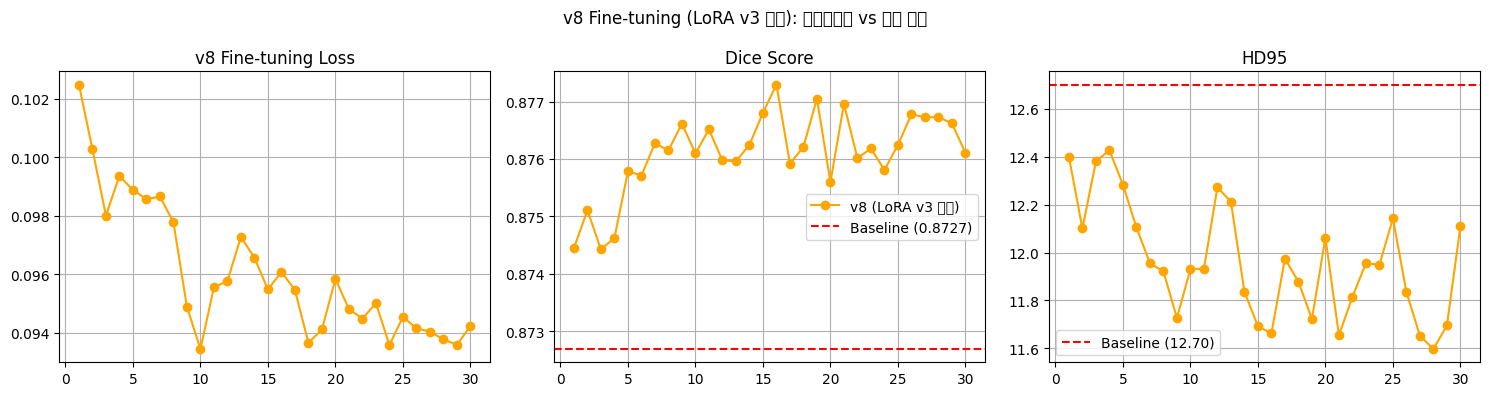

완료!


In [ ]:
# [Phase 3-v3] Fine-tuning: 베이스라인 + synthetic_v8 (LoRA v3 패치 방식)
# synthetic_v7(LoRA v4)과 비교하기 위한 실험

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import cv2, json, os, random
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device: {device}")

SYNTHETIC_V8  = Path(BME_DIR) / 'synthetic_v8'
FINETUNE_V3   = Path(CHECKPOINTS_DIR) / 'seg_finetune_v8_mixed'
BASELINE_CKPT = Path(CHECKPOINTS_DIR) / 'seg_baseline_1000' / 'best.pth'
FINETUNE_V3.mkdir(parents=True, exist_ok=True)

# ──────────────────────────────────────────────
# 1. 모델 구조 (동일)
# ──────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)

class DownSample(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = ConvBlock(in_ch, out_ch, dropout)
    def forward(self, x): return self.conv(self.pool(x))

class UpSample(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.0):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = ConvBlock(in_ch + skip_ch, out_ch, dropout)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.pad(x, [0, skip.shape[-1]-x.shape[-1],
                          0, skip.shape[-2]-x.shape[-2]])
        return self.conv(torch.cat([x, skip], dim=1))

class AttentionGate(nn.Module):
    def __init__(self, g_ch, x_ch, inter_ch):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_ch, inter_ch, 1, bias=False), nn.BatchNorm2d(inter_ch))
        self.W_x = nn.Sequential(
            nn.Conv2d(x_ch, inter_ch, 1, bias=False), nn.BatchNorm2d(inter_ch))
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, 1, bias=False), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        g1 = self.W_g(g); x1 = self.W_x(x)
        if g1.shape[-2:] != x1.shape[-2:]:
            g1 = F.interpolate(g1, size=x1.shape[-2:],
                               mode='bilinear', align_corners=True)
        return x * self.psi(self.relu(g1 + x1))

class AttentionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1,
                 features=None, dropout=0.2):
        super().__init__()
        if features is None:
            features = [64, 128, 256, 512]
        self.enc1       = ConvBlock(in_channels, features[0])
        self.enc2       = DownSample(features[0], features[1], dropout)
        self.enc3       = DownSample(features[1], features[2], dropout)
        self.enc4       = DownSample(features[2], features[3], dropout)
        self.bottleneck = DownSample(features[3], features[3]*2, dropout)
        self.att4 = AttentionGate(features[3]*2, features[3], features[3]//2)
        self.att3 = AttentionGate(features[3],   features[2], features[2]//2)
        self.att2 = AttentionGate(features[2],   features[1], features[1]//2)
        self.att1 = AttentionGate(features[1],   features[0], features[0]//2)
        self.dec4 = UpSample(features[3]*2, features[3], features[3], dropout)
        self.dec3 = UpSample(features[3],   features[2], features[2], dropout)
        self.dec2 = UpSample(features[2],   features[1], features[1], dropout)
        self.dec1 = UpSample(features[1],   features[0], features[0], dropout)
        self.head = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        b  = self.bottleneck(s4)
        d4 = self.dec4(b,  self.att4(b,  s4))
        d3 = self.dec3(d4, self.att3(d4, s3))
        d2 = self.dec2(d3, self.att2(d3, s2))
        d1 = self.dec1(d2, self.att1(d2, s1))
        return self.head(d1)

# ──────────────────────────────────────────────
# 2. 데이터셋
# ──────────────────────────────────────────────
class BraTSDataset(Dataset):
    def __init__(self, brats_dir, split='train',
                 val_ratio=0.15, test_ratio=0.10, seed=42):
        img_dir  = Path(brats_dir) / 'images'
        mask_dir = Path(brats_dir) / 'masks'
        all_imgs = sorted(img_dir.glob('*_t1ce.png'))
        pairs = []
        for ip in all_imgs:
            mp = mask_dir / ip.name.replace('_t1ce', '_seg')
            if mp.exists():
                pairs.append((ip, mp))
        rng = random.Random(seed)
        rng.shuffle(pairs)
        n      = len(pairs)
        n_test = max(1, int(n * test_ratio))
        n_val  = max(1, int(n * val_ratio))
        if split == 'test':
            self.pairs = pairs[:n_test]
        elif split == 'val':
            self.pairs = pairs[n_test:n_test+n_val]
        else:
            self.pairs = pairs[n_test+n_val:]
        print(f"BraTSDataset [{split}]: {len(self.pairs)}장")

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        ip, mp = self.pairs[idx]
        img  = np.array(Image.open(ip).convert('L'),
                        dtype=np.float32) / 255.0
        mask = (np.array(Image.open(mp).convert('L')) > 0).astype(np.float32)
        img  = cv2.resize(img,  (256,256), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (256,256), interpolation=cv2.INTER_NEAREST)
        if np.random.rand() > 0.5:
            img  = np.fliplr(img).copy()
            mask = np.fliplr(mask).copy()
        return {
            'image': torch.from_numpy(img).unsqueeze(0).float(),
            'mask':  torch.from_numpy(mask).unsqueeze(0).float()
        }

class SyntheticDataset(Dataset):
    def __init__(self, syn_dir, augment=True):
        self.syn_dir   = Path(syn_dir)
        self.img_files = sorted(self.syn_dir.glob('*_synthetic.png'))
        self.augment   = augment
        print(f"SyntheticDataset: {len(self.img_files)}장")

    def __len__(self): return len(self.img_files)

    def __getitem__(self, idx):
        img_path  = self.img_files[idx]
        mask_name = img_path.name.replace('_synthetic.png', '_mask.png')
        mask_path = self.syn_dir / 'gt_masks' / mask_name
        img  = np.array(Image.open(img_path).convert('L').resize((256,256)),
                        dtype=np.float32) / 255.0
        mask = (np.array(Image.open(mask_path).convert('L').resize((256,256)))
                > 127).astype(np.float32)
        if self.augment:
            if np.random.rand() > 0.5:
                img  = np.fliplr(img).copy()
                mask = np.fliplr(mask).copy()
            if np.random.rand() > 0.5:
                img  = np.flipud(img).copy()
                mask = np.flipud(mask).copy()
            angle = np.random.uniform(-30, 30)
            M = cv2.getRotationMatrix2D((128,128), angle, 1.0)
            img  = cv2.warpAffine(img,  M, (256,256), flags=cv2.INTER_LINEAR)
            mask = cv2.warpAffine(mask, M, (256,256), flags=cv2.INTER_NEAREST)
        return {
            'image': torch.from_numpy(img).unsqueeze(0).float(),
            'mask':  torch.from_numpy(mask).unsqueeze(0).float()
        }

# ──────────────────────────────────────────────
# 3. 손실 함수 및 평가 지표
# ──────────────────────────────────────────────
def dice_loss(pred, target, smooth=1e-6):
    pred  = torch.sigmoid(pred)
    inter = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    return 1 - ((2*inter+smooth)/(union+smooth)).mean()

def combined_loss(pred, target):
    return (0.6*dice_loss(pred,target) +
            0.4*F.binary_cross_entropy_with_logits(pred,target))

@torch.no_grad()
def compute_metrics(pred_logits, target):
    pred      = (torch.sigmoid(pred_logits) > 0.5).float()
    pred_np   = pred.cpu().numpy().astype(bool)
    target_np = target.cpu().numpy().astype(bool)
    d_list, i_list, h_list = [], [], []
    for p, t in zip(pred_np, target_np):
        p = p[0]; t = t[0]
        inter = (p & t).sum()
        d_list.append((2*inter) / (p.sum()+t.sum()+1e-6))
        i_list.append(inter / ((p|t).sum()+1e-6))
        if p.sum() > 0 and t.sum() > 0:
            hd1 = distance_transform_edt(~p)[t].max()
            hd2 = distance_transform_edt(~t)[p].max()
            h_list.append(float(np.percentile([hd1,hd2], 95)))
        else:
            h_list.append(373.0)
    return np.mean(d_list), np.mean(i_list), np.mean(h_list)

# ──────────────────────────────────────────────
# 4. 데이터 분리 확인
# ──────────────────────────────────────────────
test_dataset = BraTSDataset(BRATS_SLICES, split='test',
                             val_ratio=0.15, test_ratio=0.10, seed=42)
brats_train  = BraTSDataset(BRATS_SLICES, split='train',
                             val_ratio=0.15, test_ratio=0.10, seed=42)

train_names = set(str(p[0].name) for p in brats_train.pairs)
test_names  = set(str(p[0].name) for p in test_dataset.pairs)
assert len(train_names & test_names) == 0, "train/test 데이터 겹침!"
print(f"train/test 분리 확인 완료!")

# ──────────────────────────────────────────────
# 5. 데이터로더
# ──────────────────────────────────────────────
test_loader  = DataLoader(test_dataset, batch_size=16,
                          shuffle=False, num_workers=2)
syn_dataset  = SyntheticDataset(SYNTHETIC_V8, augment=True)
random.seed(42)
brats_indices = random.sample(range(len(brats_train)), min(300, len(brats_train)))
brats_subset  = torch.utils.data.Subset(brats_train, brats_indices)
mixed_dataset = ConcatDataset([syn_dataset, brats_subset])
mixed_loader  = DataLoader(mixed_dataset, batch_size=16,
                           shuffle=True, num_workers=2, drop_last=True)
print(f"혼합 데이터셋: {len(mixed_dataset)}장 ({len(mixed_loader)} 배치)")

# ──────────────────────────────────────────────
# 6. 모델 + Resume 체크
# ──────────────────────────────────────────────
model = AttentionUNet(in_channels=1, out_channels=1,
                      features=[64,128,256,512], dropout=0.2).to(device)

NUM_EPOCHS  = 30
start_epoch = 1
history     = {'epoch':[], 'train_loss':[], 'dice':[], 'iou':[], 'hd95':[]}

epoch_ckpts = sorted(FINETUNE_V3.glob('epoch_*.pth'))
if epoch_ckpts:
    latest  = epoch_ckpts[-1]
    ckpt_r  = torch.load(latest, map_location=device, weights_only=False)
    model.load_state_dict(ckpt_r['model'])
    history     = ckpt_r['history']
    start_epoch = ckpt_r['epoch'] + 1
    best_dice   = ckpt_r['best_dice']
    baseline_dice = ckpt_r.get('baseline_dice', 0.8731)
    baseline_iou  = ckpt_r.get('baseline_iou',  0.0)
    baseline_hd95 = ckpt_r.get('baseline_hd95', 0.0)
    optimizer    = torch.optim.AdamW(model.parameters(), lr=5e-6, weight_decay=1e-5)
    scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
    optimizer.load_state_dict(ckpt_r['optimizer'])
    for _ in range(ckpt_r['epoch']):
        scheduler_lr.step()
    print(f"Resume: epoch {start_epoch}부터 | best_dice={best_dice:.4f}")
else:
    ckpt = torch.load(BASELINE_CKPT, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model'])
    print(f"베이스라인 로드! best_dice={ckpt['best_dice']:.4f}")

    model.eval()
    d_list, i_list, h_list = [], [], []
    for batch in tqdm(test_loader, desc='베이스라인 평가'):
        imgs  = batch['image'].to(device)
        masks = batch['mask'].to(device)
        with torch.no_grad():
            preds = model(imgs)
        d, i, h = compute_metrics(preds, masks)
        d_list.append(d); i_list.append(i); h_list.append(h)

    baseline_dice = float(np.mean(d_list))
    baseline_iou  = float(np.mean(i_list))
    baseline_hd95 = float(np.mean(h_list))
    best_dice     = baseline_dice
    optimizer    = torch.optim.AdamW(model.parameters(), lr=5e-6, weight_decay=1e-5)
    scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
    print(f"베이스라인: Dice={baseline_dice:.4f} | IoU={baseline_iou:.4f} | HD95={baseline_hd95:.2f}")

scaler = torch.cuda.amp.GradScaler()

print(f"\n[v8 Mixed Fine-tuning] epoch {start_epoch}~{NUM_EPOCHS}")
print(f"synthetic_v8(LoRA v3 패치) + BraTS 300장")
print(f"베이스라인 Dice {baseline_dice:.4f} 넘으면 성공!")
print('-' * 50)

# ──────────────────────────────────────────────
# 7. 학습 루프
# ──────────────────────────────────────────────
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for batch in tqdm(mixed_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}'):
        imgs  = batch['image'].to(device)
        masks = batch['mask'].to(device)
        with torch.amp.autocast('cuda'):
            preds = model(imgs)
            loss  = combined_loss(preds, masks)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item()
    scheduler_lr.step()
    avg_loss = total_loss / len(mixed_loader)

    model.eval()
    d_list, i_list, h_list = [], [], []
    for batch in test_loader:
        imgs  = batch['image'].to(device)
        masks = batch['mask'].to(device)
        with torch.no_grad():
            preds = model(imgs)
        d, i, h = compute_metrics(preds, masks)
        d_list.append(d); i_list.append(i); h_list.append(h)

    epoch_dice = float(np.mean(d_list))
    epoch_iou  = float(np.mean(i_list))
    epoch_hd95 = float(np.mean(h_list))

    history['epoch'].append(epoch)
    history['train_loss'].append(avg_loss)
    history['dice'].append(epoch_dice)
    history['iou'].append(epoch_iou)
    history['hd95'].append(epoch_hd95)

    marker = ' ✅' if epoch_dice > baseline_dice else ''
    print(f"Epoch {epoch:02d} | loss={avg_loss:.4f} | "
          f"Dice={epoch_dice:.4f} | IoU={epoch_iou:.4f} | "
          f"HD95={epoch_hd95:.2f}{marker}")

    if epoch_dice > best_dice:
        best_dice = epoch_dice
        torch.save({
            'epoch': epoch, 'model': model.state_dict(),
            'dice': epoch_dice, 'iou': epoch_iou, 'hd95': epoch_hd95,
            'baseline_dice': baseline_dice,
            'baseline_iou':  baseline_iou,
            'baseline_hd95': baseline_hd95,
        }, FINETUNE_V3 / 'best.pth')
        print(f"  → Best 갱신! Dice={best_dice:.4f}")

    torch.save({
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'history': history,
        'best_dice': best_dice,
        'baseline_dice': baseline_dice,
        'baseline_iou':  baseline_iou,
        'baseline_hd95': baseline_hd95,
    }, FINETUNE_V3 / f'epoch_{epoch:02d}.pth')

# ──────────────────────────────────────────────
# 8. 최종 결과 비교
# ──────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"{'':25s} {'Dice':>8} {'IoU':>8} {'HD95':>8}")
print(f"{'-'*55}")
print(f"{'베이스라인':25s} {baseline_dice:>8.4f} {baseline_iou:>8.4f} {baseline_hd95:>8.2f}")

if (FINETUNE_V3 / 'best.pth').exists():
    best_r = torch.load(FINETUNE_V3/'best.pth', map_location='cpu', weights_only=False)
    print(f"{'v8 Mixed (LoRA v3 패치)':25s} {best_r['dice']:>8.4f} "
          f"{best_r['iou']:>8.4f} {best_r['hd95']:>8.2f}")
else:
    print(f"{'v8 Mixed (LoRA v3 패치)':25s} {max(history['dice']):>8.4f} (베이스라인 미달)")
print(f"{'='*55}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['epoch'], history['train_loss'], marker='o', color='orange')
axes[0].set_title('v8 Fine-tuning Loss'); axes[0].grid(True)

axes[1].plot(history['epoch'], history['dice'], marker='o',
             color='orange', label='v8 (LoRA v3 패치)')
axes[1].axhline(y=baseline_dice, color='red', linestyle='--',
                label=f'Baseline ({baseline_dice:.4f})')
axes[1].set_title('Dice Score'); axes[1].legend(); axes[1].grid(True)

axes[2].plot(history['epoch'], history['hd95'], marker='o', color='orange')
axes[2].axhline(y=baseline_hd95, color='red', linestyle='--',
                label=f'Baseline ({baseline_hd95:.2f})')
axes[2].set_title('HD95'); axes[2].legend(); axes[2].grid(True)

plt.suptitle('v8 Fine-tuning (LoRA v3 패치): 베이스라인 vs 제안 방법')
plt.tight_layout()
plt.savefig('v8_finetune_results.png', dpi=100)
plt.show()

with open(FINETUNE_V3 / 'history.json', 'w') as f:
    json.dump(history, f, indent=2)
print("완료!")

In [ ]:
# [확인] v8 best.pth 상세 확인

import torch
from pathlib import Path

best = torch.load(
    Path(CHECKPOINTS_DIR) / 'seg_finetune_v8_mixed' / 'best.pth',
    map_location='cpu', weights_only=False
)
print(f"epoch: {best['epoch']}")
print(f"Dice:  {best['dice']:.4f}")
print(f"IoU:   {best['iou']:.4f}")
print(f"HD95:  {best['hd95']:.2f}")
print(f"baseline_dice: {best.get('baseline_dice', 'N/A')}")

# history 확인
ckpts = sorted((Path(CHECKPOINTS_DIR) / 'seg_finetune_v8_mixed').glob('epoch_*.pth'))
print(f"\n저장된 체크포인트: {len(ckpts)}개")
print(f"범위: {ckpts[0].name} ~ {ckpts[-1].name}")

epoch: 16
Dice:  0.8773
IoU:   0.7918
HD95:  11.66
baseline_dice: 0.8726856707951021

저장된 체크포인트: 30개
범위: epoch_01.pth ~ epoch_30.pth


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 159MB/s] 
BraTS 종양 슬라이스 필터링: 100%|██████████| 3000/3000 [16:09<00:00,  3.09it/s]


BraTS 종양 슬라이스: 2544장

BraTS feature 추출 중...


BraTS feature: 100%|██████████| 500/500 [02:52<00:00,  2.89it/s]



synthetic_v7 feature 추출 중...


v7 feature: 100%|██████████| 500/500 [04:01<00:00,  2.07it/s]



synthetic_v8 feature 추출 중...


v8 feature: 100%|██████████| 500/500 [00:09<00:00, 50.82it/s]



버전                          FID            LoRA            학습방식
--------------------------------------------------
synthetic_v5               96.4              v3           패치 크롭
synthetic_v7             133.79              v4         전체 슬라이스
synthetic_v8             133.65              v3     패치 크롭+blend

낮을수록 좋음 (참고: MCFDiffusion=70.58)


/tmp/ipykernel_1940/2015489039.py:118: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1940/2015489039.py:118: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1940/2015489039.py:118: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1940/2015489039.py:118: UserWarning: Glyph 47213 (\N{HANGUL SYLLABLE ROB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1940/2015489039.py:118: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1940/2015489039.py:118: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1940/2015489039.py:118: UserWarning: Glyph 49836 (\N{HANGUL SYLLABLE SEUL}) missing from font(s) DejaVu Sans.
  plt.

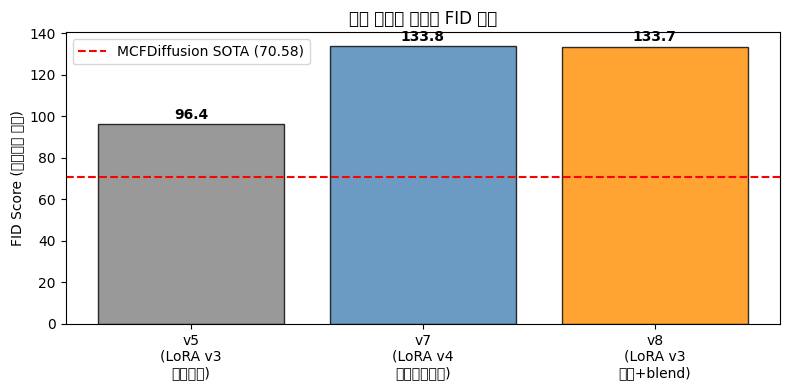

In [ ]:
# [평가] FID Score 측정 - synthetic_v8 vs BraTS 비교

import torch
import numpy as np
from pathlib import Path
from PIL import Image
from torchvision import transforms
from torchvision.models import inception_v3, Inception_V3_Weights
from scipy.linalg import sqrtm
from tqdm import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'

SYNTHETIC_V7 = Path(BME_DIR) / 'synthetic_v7'
SYNTHETIC_V8 = Path(BME_DIR) / 'synthetic_v8'

# ──────────────────────────────────────────────
# 1. Inception v3 로드
# ──────────────────────────────────────────────
inception = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1,
                         transform_input=False)
inception.fc = torch.nn.Identity()
inception = inception.to(device).eval()

transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# ──────────────────────────────────────────────
# 2. Feature 추출 함수
# ──────────────────────────────────────────────
@torch.no_grad()
def extract_features(img_paths, max_samples=500, desc='추출'):
    features = []
    sampled  = list(img_paths)[:max_samples]
    for path in tqdm(sampled, desc=desc):
        try:
            img  = Image.open(path).convert('RGB')
            img  = transform(img).unsqueeze(0).to(device)
            feat = inception(img)
            features.append(feat.squeeze().cpu().numpy())
        except:
            continue
    return np.array(features)

def compute_fid(feat1, feat2):
    mu1, sigma1 = feat1.mean(axis=0), np.cov(feat1, rowvar=False)
    mu2, sigma2 = feat2.mean(axis=0), np.cov(feat2, rowvar=False)
    diff    = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))

# ──────────────────────────────────────────────
# 3. BraTS 종양 슬라이스 필터링 (공통 기준)
# ──────────────────────────────────────────────
brats_img_dir = Path(BRATS_SLICES) / 'images'
brats_msk_dir = Path(BRATS_SLICES) / 'masks'
brats_files   = sorted(brats_img_dir.glob('*_t1ce.png'))

brats_tumor_files = []
for ip in tqdm(brats_files[:3000], desc='BraTS 종양 슬라이스 필터링'):
    mp = brats_msk_dir / ip.name.replace('_t1ce', '_seg')
    if mp.exists():
        mask = np.array(Image.open(mp).convert('L'))
        if (mask > 0).mean() >= 0.01:
            brats_tumor_files.append(ip)
print(f"BraTS 종양 슬라이스: {len(brats_tumor_files)}장")

# ──────────────────────────────────────────────
# 4. Feature 추출
# ──────────────────────────────────────────────
print("\nBraTS feature 추출 중...")
brats_features = extract_features(brats_tumor_files, max_samples=500,
                                   desc='BraTS feature')

print("\nsynthetic_v7 feature 추출 중...")
syn_v7_files   = sorted(SYNTHETIC_V7.glob('*_synthetic.png'))
v7_features    = extract_features(syn_v7_files, max_samples=500,
                                   desc='v7 feature')

print("\nsynthetic_v8 feature 추출 중...")
syn_v8_files   = sorted(SYNTHETIC_V8.glob('*_synthetic.png'))
v8_features    = extract_features(syn_v8_files, max_samples=500,
                                   desc='v8 feature')

# ──────────────────────────────────────────────
# 5. FID 계산 및 비교
# ──────────────────────────────────────────────
fid_v7 = compute_fid(brats_features, v7_features)
fid_v8 = compute_fid(brats_features, v8_features)

print(f"\n{'='*50}")
print(f"{'버전':20s} {'FID':>10} {'LoRA':>15} {'학습방식':>15}")
print(f"{'-'*50}")
print(f"{'synthetic_v5':20s} {'96.4':>10} {'v3':>15} {'패치 크롭':>15}")
print(f"{'synthetic_v7':20s} {fid_v7:>10.2f} {'v4':>15} {'전체 슬라이스':>15}")
print(f"{'synthetic_v8':20s} {fid_v8:>10.2f} {'v3':>15} {'패치 크롭+blend':>15}")
print(f"{'='*50}")
print(f"\n낮을수록 좋음 (참고: MCFDiffusion=70.58)")

# 시각화
fig, ax = plt.subplots(figsize=(8, 4))
versions = ['v5\n(LoRA v3\n패치크롭)', 'v7\n(LoRA v4\n전체슬라이스)', 'v8\n(LoRA v3\n패치+blend)']
fids     = [96.4, fid_v7, fid_v8]
colors   = ['gray', 'steelblue', 'darkorange']
bars = ax.bar(versions, fids, color=colors, alpha=0.8, edgecolor='black')
ax.axhline(y=70.58, color='red', linestyle='--', label='MCFDiffusion SOTA (70.58)')
ax.set_ylabel('FID Score (낮을수록 좋음)')
ax.set_title('합성 데이터 버전별 FID 비교')
ax.legend()
for bar, fid in zip(bars, fids):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{fid:.1f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('fid_comparison.png', dpi=100)
plt.show()

/tmp/ipykernel_1940/3659432142.py:28: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1940/3659432142.py:28: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1940/3659432142.py:28: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1940/3659432142.py:28: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1940/3659432142.py:29: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.savefig('v8_full_results.png', dpi=100)
/tmp/ipykernel_1940/3659432142.py:29: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.savefig('v8_full_results.png', dpi=100)
/tmp/ipykernel_1940/3659432142.py:29: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE G

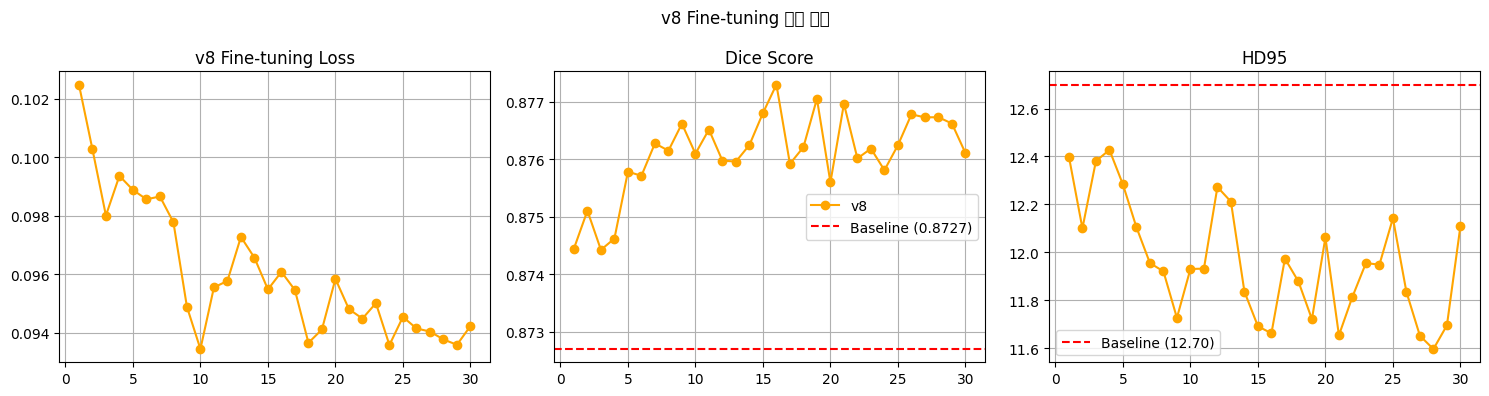

Best Dice: epoch 16 → 0.8773
Best HD95: epoch 28 → 11.60


In [ ]:
# [확인] v8 전체 history 시각화

import json, matplotlib.pyplot as plt
from pathlib import Path

with open(Path(CHECKPOINTS_DIR) / 'seg_finetune_v8_mixed' / 'history.json') as f:
    h = json.load(f)

baseline_dice = 0.8727
baseline_hd95 = 12.70

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(h['epoch'], h['train_loss'], marker='o', color='orange')
axes[0].set_title('v8 Fine-tuning Loss'); axes[0].grid(True)

axes[1].plot(h['epoch'], h['dice'], marker='o', color='orange', label='v8')
axes[1].axhline(y=baseline_dice, color='red', linestyle='--',
                label=f'Baseline ({baseline_dice:.4f})')
axes[1].set_title('Dice Score'); axes[1].legend(); axes[1].grid(True)

axes[2].plot(h['epoch'], h['hd95'], marker='o', color='orange')
axes[2].axhline(y=baseline_hd95, color='red', linestyle='--',
                label=f'Baseline ({baseline_hd95:.2f})')
axes[2].set_title('HD95'); axes[2].legend(); axes[2].grid(True)

plt.suptitle('v8 Fine-tuning 전체 결과')
plt.tight_layout()
plt.savefig('v8_full_results.png', dpi=100)
plt.show()

print(f"Best Dice: epoch {h['epoch'][h['dice'].index(max(h['dice']))]} → {max(h['dice']):.4f}")
print(f"Best HD95: epoch {h['epoch'][h['hd95'].index(min(h['hd95']))]} → {min(h['hd95']):.2f}")